<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC2</p>
<p style="margin: 0; text-align:right;">2025-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 2: Redes neuronales recurrentes con Keras


<u>Consideraciones generales</u>:

- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# 0. Contexto y carga de librerías

En esta práctica exploraremos el uso de **Redes Neuronales Recurrentes (RNN)** y sus variantes modernas (LSTM, GRU) aplicadas a diferentes problemas de series temporales y procesamiento de legunaje natural. Las RNN son especialmente útiles cuando los datos presentan una **estructura secuencial**, ya que permiten capturar dependencias a lo largo del tiempo o del texto.

En los ejercicios se trabajarán desde ejemplos sintéticos hasta aplicaciones reales en finanzas, análisis de sentiemientos y predicción meteorológica, con el objetivo de comprender tanto el uso práctico de estas arquitecturas como sus limitaciones.

A continuación se incluyen las librerías necesarias para realizar esta PEC:

In [37]:
# Proporciona funciones para interactuar con el sistema operativo (como rutas de archivos)
import os

# Permite modificar aspectos del entorno de ejecución de Python, como la lista de rutas de búsqueda de módulos (sys.path)
import sys

# Sube un nivel desde /PEC/
root_dir = os.path.abspath('..')
sys.path.append(root_dir)

# Análisis y manipulación de datos
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
# Estilo
sns.set(style="whitegrid")

# Operaciones matematicas y vectorizacion
import numpy as np
import random

# Librerias para DL
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Para guardar modelos y resultados
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import SimpleRNN, Dense, Input, GRU, LSTM, Dropout, Embedding, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

# Comprobar valores de RAM (CPU/GPU) y Disco
import psutil
import shutil

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Guardar los modelos entrenados y sus historiales
import pickle

In [38]:
# 1. RAM del Sistema (CPU RAM)
ram = psutil.virtual_memory()
print(f"--- RAM DEL SISTEMA ---")
print(f"Total: {ram.total / 1e9:.2f} GB")
print(f"En uso: {ram.used / 1e9:.2f} GB")
print(f"Disponible: {ram.available / 1e9:.2f} GB")

# 2. Espacio en Disco
total, used, free = shutil.disk_usage("/")
print(f"\n--- DISCO DURO ---")
print(f"Total: {total / 1e9:.2f} GB")
print(f"Usado: {used / 1e9:.2f} GB")
print(f"Libre: {free / 1e9:.2f} GB")

# 3. RAM de la GPU (VRAM)
print(f"\n--- GPU (ACELERADOR) ---")
if torch.cuda.is_available():
    # Obtener el nombre de la GPU
    gpu_name = torch.cuda.get_device_name(0)
    # Obtener memoria total y reservada
    total_vram = torch.cuda.get_device_properties(0).total_memory
    reserved_vram = torch.cuda.memory_reserved(0)
    allocated_vram = torch.cuda.memory_allocated(0)
    free_vram = total_vram - allocated_vram

    print(f"Modelo: {gpu_name}")
    print(f"VRAM Total: {total_vram / 1e9:.2f} GB")
    print(f"VRAM Libre: {free_vram / 1e9:.2f} GB")
else:
    print("No se detectó GPU.")

--- RAM DEL SISTEMA ---
Total: 8.35 GB
En uso: 7.19 GB
Disponible: 1.16 GB

--- DISCO DURO ---
Total: 510.42 GB
Usado: 144.62 GB
Libre: 365.80 GB

--- GPU (ACELERADOR) ---
No se detectó GPU.


# 1. RNN básica

En este ejercicio vamos a explorar cómo una **Red Neuronal Recurrente (RNN)** puede aprender patrones en datos de series temporales. Las RNN son un tipo de red diseñado para manejar secuencias, ya que no procesan los datos como entradas independientes, sino que mantienen un estado interno que les permite recordar información sobre pasos previos. Esto las hace especialmente útiles en tareas como predicción de series temporales, procesamiento de lenguaje natural (NLP) o análisis de señales.

Trabajaremos con una serie temporal para la predicción de la temperatura del aceite de transformadores eléctricos. Más información sobre el dataset: https://github.com/zhouhaoyi/ETDataset

En el modelado de series temporales, el parámetro `window_size` es fundamental. Representa el **número de pasos anteriores** que el modelo utilizará como entrada para predecir el siguiente valor. Podemos imaginarlo como una **ventana deslizante** (o sliding window) que se mueve a lo largo de la serie. En cada posición, recoge un bloque de datos pasados y lo utiliza para estimar el valor futuro inmediato. Por ejemplo, si `window_size = 5`, y tenemos la serie `1, 2, 3, 4, 5, 6, 7`, la red recibiría como entrada `[1, 2, 3, 4, 5]` y debería predecir como salida `6`.


Por otra parte, la **reproducibilidad** es la capacidad de obtener los **mismos resultados** cuando un experimento se repite bajo las mismas condiciones: mismo código, mismos datos de entrada, mismos hiperparámetros, mismo entorno de ejecución. En deep learning, lograr la reproducibilidad es más difícil por varias razones:
- Inicialización aleatoria de pesos de la red.
- Barajado aleatorio (shuffling) de los datos durante el entrenamiento.
- Aritmética de coma flotante. Las sumas de coma flotante no tienen porque seguir la propiedad asociativa debido al redondeo. Además, en las GPUs el orden de las operaciones puede cambiar entre ejecuciones.

Para solucionar esto, se fijan semillas aleatorias (**random seeds**) en todos los componentes que generan números aleatorios:
```python
np.random.seed()
random.seed()
tf.random.set_seed() (para TensorFlow)
```

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2.5 pts.].** Carga los datos con la serie temporal, entrena una RNN simple con distintos tamaños de ventana, compara los resultados y visualizalos. Para ello:
- Descarga el dataset con una muestra reducida de los datos https://github.com/zhouhaoyi/ETDataset/blob/main/ETT-small/ETTh1.csv
- Realiza un breve análisis exploratorio de los datos.
- Preprocesa los datos de entrada.  
    - Crea una función para convertir los datos en secuencias supervisadas. Dado un tamaño de ventana (`window_size`) ha de dividir la serie en secuencias de entrada (una subventana de longitud `window_size`) y valores de salida (el valor siguiente a cada ventana).
    - Divide los datos en 70% para entrenamiento, 15% para validación y 15% para test.
    - Escala los valores entre 0 y 1.     
- Crea un modelo secuencial con:
    - Una capa `SimpleRNN` y una capa de salida `Dense`.
    - Compila el modelo con loss `mean_squared_error` y optimizador `Adam`.
    - Usa semillas aleatorias para mantener la reproducibilidad.
- Calcula el RMSE (Root Mean Squared Error) y MAE (Mean Squared Error) para los tres subconjuntos de datos. Guarda los resultados en una tabla para hacer comparaciones posteriores.
- Visualiza las curvas de loss por epoch y los valores reales vs. valores predichos. Recuerda desescalar las variables para ver los valores reales y no los normalizados.

Responde a las siguientes preguntas:
- ¿Por qué deben convertirse los datos de series temporales en ventanas deslizantes?
- ¿Qué limitaciones tiene una SimpleRNN para datos con secuencias temporales largas?
</div>


He creado dos funciones que se utilizan a lo largo de la PEC:

- La primera, **`resumen_dataset()`**, genera un resumen completo del DataFrame, mostrando su forma, tipos de datos, valores nulos, y estadísticas básicas, además del rango de fechas.
- La segunda, **`create_sequences()`**, Convierte un array de datos en secuencias X (ventanas) e y (objetivo).

In [39]:
def resumen_dataset(df, nombre="Dataset"):
    '''
    Imprime un resumen completo del dataset, incluyendo:
        - Dimensiones
        - Rango temporal
        - Tipos de datos
        - Primeras filas
        - Estadísticas descriptivas
        - Valores nulos (con conteo y porcentaje)
    '''
    n_filas, n_cols = df.shape
    fecha_min, fecha_max = df.index.min(), df.index.max()

    print("="*60)
    print(f"RESUMEN DEL DATASET: {nombre}")
    print("="*60)

    # Información general
    print("\nINFORMACIÓN GENERAL")
    print(f"- Dimensiones        : {n_filas:,} filas × {n_cols} columnas")
    print(f"- Rango temporal     : {fecha_min} -> {fecha_max}")

    # Tipos de datos
    print("\n- Tipos de datos:")
    print(df.dtypes.value_counts())

    # Primeras filas
    print("\nPRIMERAS FILAS")
    print(df.head())

    # Estadísticas
    print("\nESTADÍSTICAS DESCRIPTIVAS")
    print(df.describe())

    # Nulos
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]

    print("\nVALORES NULOS")
    if len(nulos) == 0:
        print("No hay valores nulos")
    else:
        nulos_pct = (nulos / n_filas * 100).round(2)
        resumen_nulos = pd.DataFrame({
            "Nulos": nulos,
            "%": nulos_pct
        })
        print(resumen_nulos)

    print("="*60)


def create_sequences(data, window_size):
    """
    Convierte un array de datos en secuencias X (ventanas) e y (objetivo).

    Params:
    - data: Array de datos con forma [muestras, features]
    - window_size: Número de pasos de tiempo a incluir en cada secuencia X

    Returns:
    X: Secuencia de 'window_size' pasos con todas las variables.
        - Tendrá forma [muestras, window_size, features]
    y: Valor de la variable 'OT' en el paso siguiente.
        - Tendrá forma [muestras,] (predicción del siguiente valor de 'OT')
    """

    X, y = [], []

    for i in range(len(data) - window_size):
        # Tomamos todas las variables en la ventana i : i + window_size
        X.append(data[i : (i + window_size), :])

        # El objetivo (target) es la columna 'OT' (última posición) del siguiente paso
        y.append(data[i + window_size, -1])

    return np.array(X), np.array(y)

def create_sequences_multistep(data, window_size, horizon):
    """

    """

    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        # Secuencia de entrada (todas las variables)
        X.append(data[i : (i + window_size), :])

        # Secuencia de salida: las siguientes 'horizon' horas de la variable 'OT' (índice -1)
        y.append(data[i + window_size : i + window_size + horizon, -1])
        
    return np.array(X), np.array(y)


def evaluate_multistep(model, X, y_scaled):
    """
    Función para evaluar multistep desescalando correctamente
    """
    y_pred_scaled = model.predict(X, verbose=0)
    
    # Desescalar matrices [N, 10] con un scaler de [N, 1]
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
    y_real = target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(y_scaled.shape)
    
    # Error promedio por muestra 
    mse = mean_squared_error(y_real, y_pred)
    rmse = root_mean_squared_error(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    
    return mse, rmse, mae, y_real, y_pred

## 1.1. Carga del *Electricity Transformer Dataset (ETDataset)*

El dataset ETT-small (*Electricity Transformer Temperature*) se enmarca en el problema de la distribución eléctrica, donde uno de los mayores retos es predecir la demanda futura de energía. Esta demanda es altamente variable y depende de múltiples factores como el día de la semana, estaciones del año, condiciones climáticas o eventos puntuales. La falta de modelos precisos de predicción a largo plazo obliga a los gestores a sobredimensionar la capacidad, lo que provoca ineficiencias operativas, desperdicio energético y desgaste innecesario del equipamiento.

En este contexto, la variable **temperatura del aceite del transformador (OT, *Oil Temperature*)** juega un papel clave, ya que actúa como un indicador directo del estado y la carga del transformador. Un incremento excesivo en la temperatura puede señalar condiciones de sobrecarga o riesgo operativo, mientras que valores estables indican un funcionamiento dentro de rangos seguros. Por tanto, modelar y predecir esta variable permite:

* Optimizar la gestión de la carga eléctrica.
* Prevenir fallos en transformadores.
* Reducir costes operativos y mantenimiento.
* Evitar sobreestimaciones en la planificación energética.

In [40]:
# Ruta del dataset
ruta_csv = r'..\Data\ETTh1.csv'

# Cargar el dataset
data = pd.read_csv(ruta_csv, sep=',', decimal='.', parse_dates=['date'], index_col='date')

# Mostrar las primeras filas del dataset
data.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.83,2.01,1.60,0.46,4.20,1.34,30.53
2016-07-01 01:00:00,5.69,2.08,1.49,0.43,4.14,1.37,27.79
2016-07-01 02:00:00,5.16,1.74,1.28,0.35,3.78,1.22,27.79
2016-07-01 03:00:00,5.09,1.94,1.28,0.39,3.81,1.28,25.04
2016-07-01 04:00:00,5.36,1.94,1.49,0.46,3.87,1.28,21.95


## 1.2. Análisis exploratorio de los datos

### 1.2.1. Interpretación inicial del dataset *ETTh1* en contexto energético

#### A. Estructura temporal y naturaleza del problema

El dataset presenta **17.420 observaciones** con **7 variables numéricas**, todas en formato continuo (float64). El índice temporal abarca desde julio de 2016 hasta finales de junio de 2018, lo que sugiere una serie temporal de frecuencia horaria (aprox. 2 años completos).


#### B. Variables explicativas y variable objetivo

Todas las variables son numéricas continuas, siendo **OT (Oil Temperature)** la variable de interés. El resto de variables (`HUFL`, `HULL`, `MUFL`, `MULL`, `LUFL`, `LULL`) parecen corresponder a **diferentes cargas o mediciones operativas del transformador** en distintos niveles (alto, medio, bajo).

Una breve descripcion de cada una sería:

| Variable |Descripción                             |
| -------- |--------------------------------------- |
| `date`   |Marca temporal                          |
| `HUFL`   |High Useful Load                        |
| `HULL`   |High Useless Load                       |
| `MUFL`   |Middle Useful Load                      |
| `MULL`   |Middle Useless Load                     |
| `LUFL`   |Low Useful Load                         |
| `LULL`   |Low Useless Load                        |
| `OT`     |**Oil Temperature (variable objetivo)** |

#### C. Calidad del dato

La ausencia de valores nulos indica un dataset **completo y listo para modelado**, asi como la presencia de datos normalizados o transformados. Este preprocesado viene indicado en la descripcion de la [documentacion](https://github.com/zhouhaoyi/ETDataset/tree/main) del dataset. 

#### D. Variabilidad y comportamiento de las variables

Las variables descriptivas presentan una elevada variabilidad, con desviaciones estándar en algunos casos comparables a sus medias, lo que refleja las fluctuaciones propias de la demanda energética y la carga del sistema. En particular, la variable objetivo *OT* muestra un rango amplio y una dispersión significativa, lo que indica que la temperatura del aceite responde de forma dinámica a los cambios en la carga, incluyendo posibles picos en situaciones de mayor exigencia.

#### E. Posibles outliers y eventos extremos

La presencia de valores extremos en varias variables sugiere la existencia de picos de demanda o condiciones operativas fuera de lo habitual. En este contexto, estos valores no deben interpretarse directamente como errores, sino como posibles eventos relevantes que pueden aportar información clave sobre situaciones de estrés en el sistema.

In [41]:
resumen_dataset(data, nombre="ETTh1")

RESUMEN DEL DATASET: ETTh1

INFORMACIÓN GENERAL
- Dimensiones        : 17,420 filas × 7 columnas
- Rango temporal     : 2016-07-01 00:00:00 -> 2018-06-26 19:00:00

- Tipos de datos:
float64    7
Name: count, dtype: int64

PRIMERAS FILAS
                     HUFL  HULL  MUFL  MULL  LUFL  LULL    OT
date                                                         
2016-07-01 00:00:00  5.83  2.01  1.60  0.46  4.20  1.34 30.53
2016-07-01 01:00:00  5.69  2.08  1.49  0.43  4.14  1.37 27.79
2016-07-01 02:00:00  5.16  1.74  1.28  0.35  3.78  1.22 27.79
2016-07-01 03:00:00  5.09  1.94  1.28  0.39  3.81  1.28 25.04
2016-07-01 04:00:00  5.36  1.94  1.49  0.46  3.87  1.28 21.95

ESTADÍSTICAS DESCRIPTIVAS
          HUFL     HULL     MUFL     MULL     LUFL     LULL       OT
count 17420.00 17420.00 17420.00 17420.00 17420.00 17420.00 17420.00
mean      7.38     2.24     4.30     0.88     3.07     0.86    13.32
std       7.07     2.04     6.83     1.81     1.16     0.60     8.57
min     -22.71    -4.76   

### 1.2.2. Distribución de la variable objetivo (OT)

El análisis conjunto de la serie temporal y su distribución permite entender mejor el comportamiento de la temperatura del aceite del transformador (OT). 

A lo largo del tiempo, la variable muestra un patrón claramente no estacionario, con cambios progresivos en su nivel medio. En los primeros meses del periodo analizado se observan temperaturas elevadas, que posteriormente descienden y dan lugar a una dinámica más estable con oscilaciones moderadas. Este comportamiento sugiere la presencia de una componente estacional relevante, probablemente vinculada a factores externos como las condiciones ambientales o la variabilidad en la demanda energética.

Al observar el detalle a corto plazo, se aprecia que la temperatura no evoluciona de forma suave, sino que presenta fluctuaciones frecuentes junto con algunos picos y caídas abruptas. Estas variaciones reflejan la naturaleza dinámica del sistema eléctrico, donde la carga puede cambiar rápidamente en función del consumo o de condiciones operativas específicas.

Por su parte, la distribución de la variable confirma este comportamiento. La mayor parte de los valores se concentra en un rango intermedio de temperaturas, mientras que los valores más altos aparecen con menor frecuencia, dando lugar a una distribución asimétrica con cola hacia la derecha. Estos valores extremos, aunque poco frecuentes, son especialmente relevantes, ya que pueden estar asociados a situaciones de mayor estrés o carga en el transformador.

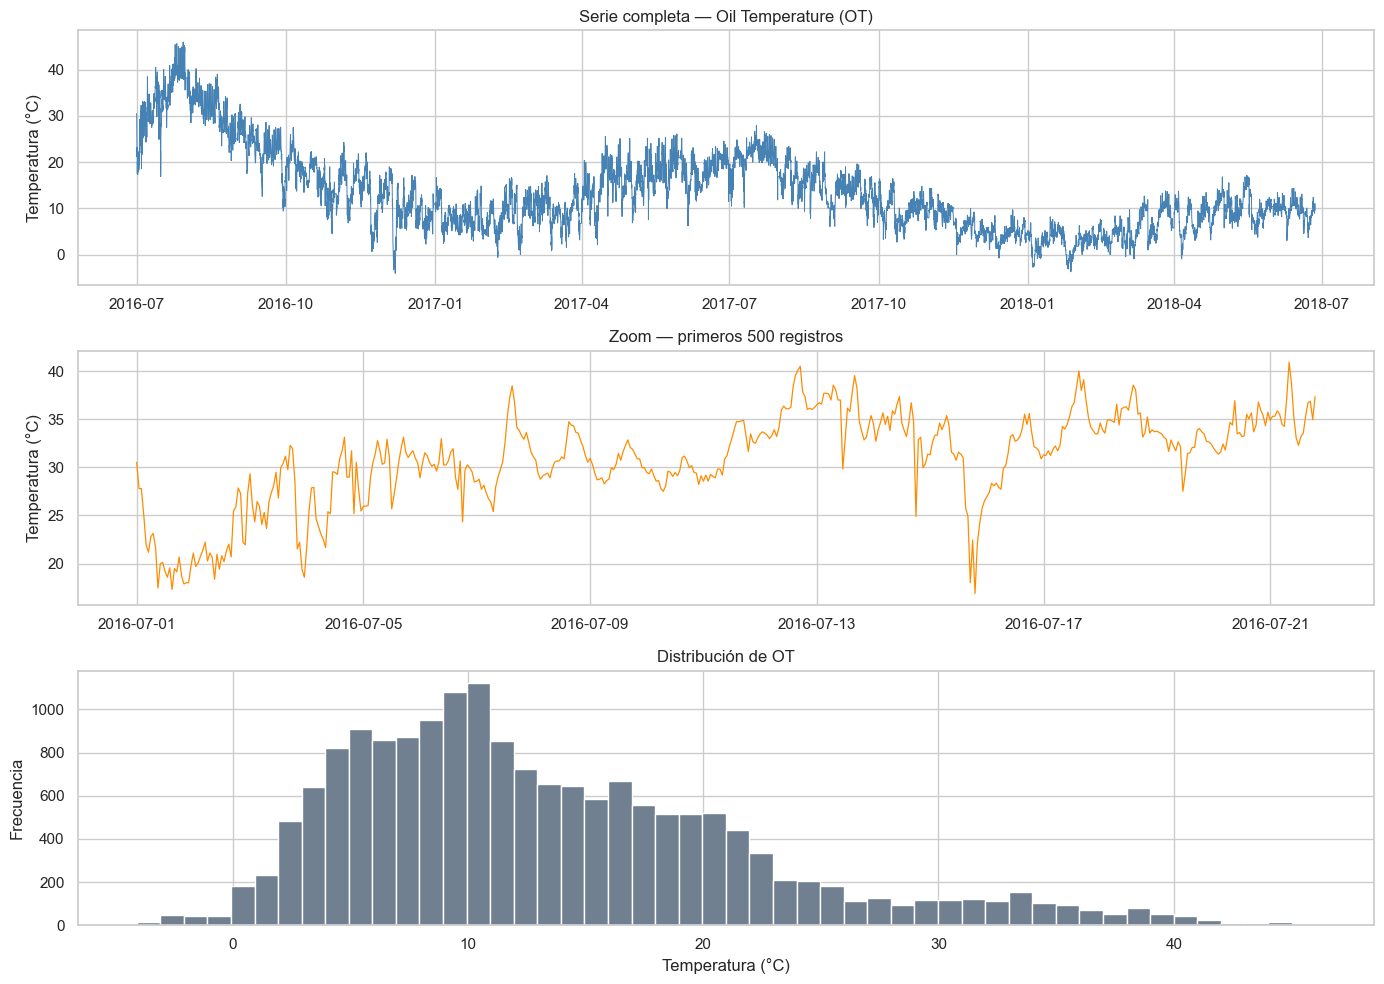

In [42]:
# Variable objetivo: temperatura del aceite del transformador (OT = Oil Temperature)
target_col = "OT"

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Serie completa
axes[0].plot(data[target_col], color="steelblue", linewidth=0.7)
axes[0].set_title("Serie completa — Oil Temperature (OT)")
axes[0].set_ylabel("Temperatura (°C)")
axes[2].set_xlabel("Temperatura (°C)")

# Zoom en los primeros 500 puntos (≈ 20 días horarios)
axes[1].plot(data[target_col].iloc[:500], color="darkorange", linewidth=0.9)
axes[1].set_title("Zoom — primeros 500 registros")
axes[1].set_ylabel("Temperatura (°C)")
axes[2].set_xlabel("Temperatura (°C)")

# Distribución
axes[2].hist(data[target_col], bins=50, color="slategray", edgecolor="white")
axes[2].set_title("Distribución de OT")
axes[2].set_xlabel("Temperatura (°C)")
axes[1].set_ylabel("Temperatura (°C)")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()

# Guardar figura
plt.savefig(r"..\images\TS-hist_OT.png", dpi=300, bbox_inches="tight")
plt.show()

### 1.2.3. Distribución de las variables descriptivas

#### A. Comportamiento temporal de las variables

El análisis de las series temporales de las variables descriptivas muestra que todas ellas presentan un comportamiento claramente no estacionario, con cambios en el nivel medio y en la variabilidad a lo largo del tiempo. Se observan patrones cíclicos recurrentes, probablemente asociados a la naturaleza periódica de la demanda eléctrica (ciclos diarios y estacionales).

En particular, variables como HUFL y MUFL presentan una elevada variabilidad con frecuentes oscilaciones y caídas bruscas, lo que sugiere una fuerte sensibilidad a cambios en la carga del sistema. Por otro lado, variables como LUFL y LULL muestran un comportamiento más estable, aunque también presentan cambios de régimen en determinados periodos.

Además, se identifican eventos puntuales abruptos (picos y caídas), que podrían corresponder a situaciones operativas específicas o anomalías en la demanda. Estos eventos son relevantes, ya que pueden influir directamente en la temperatura del transformador.

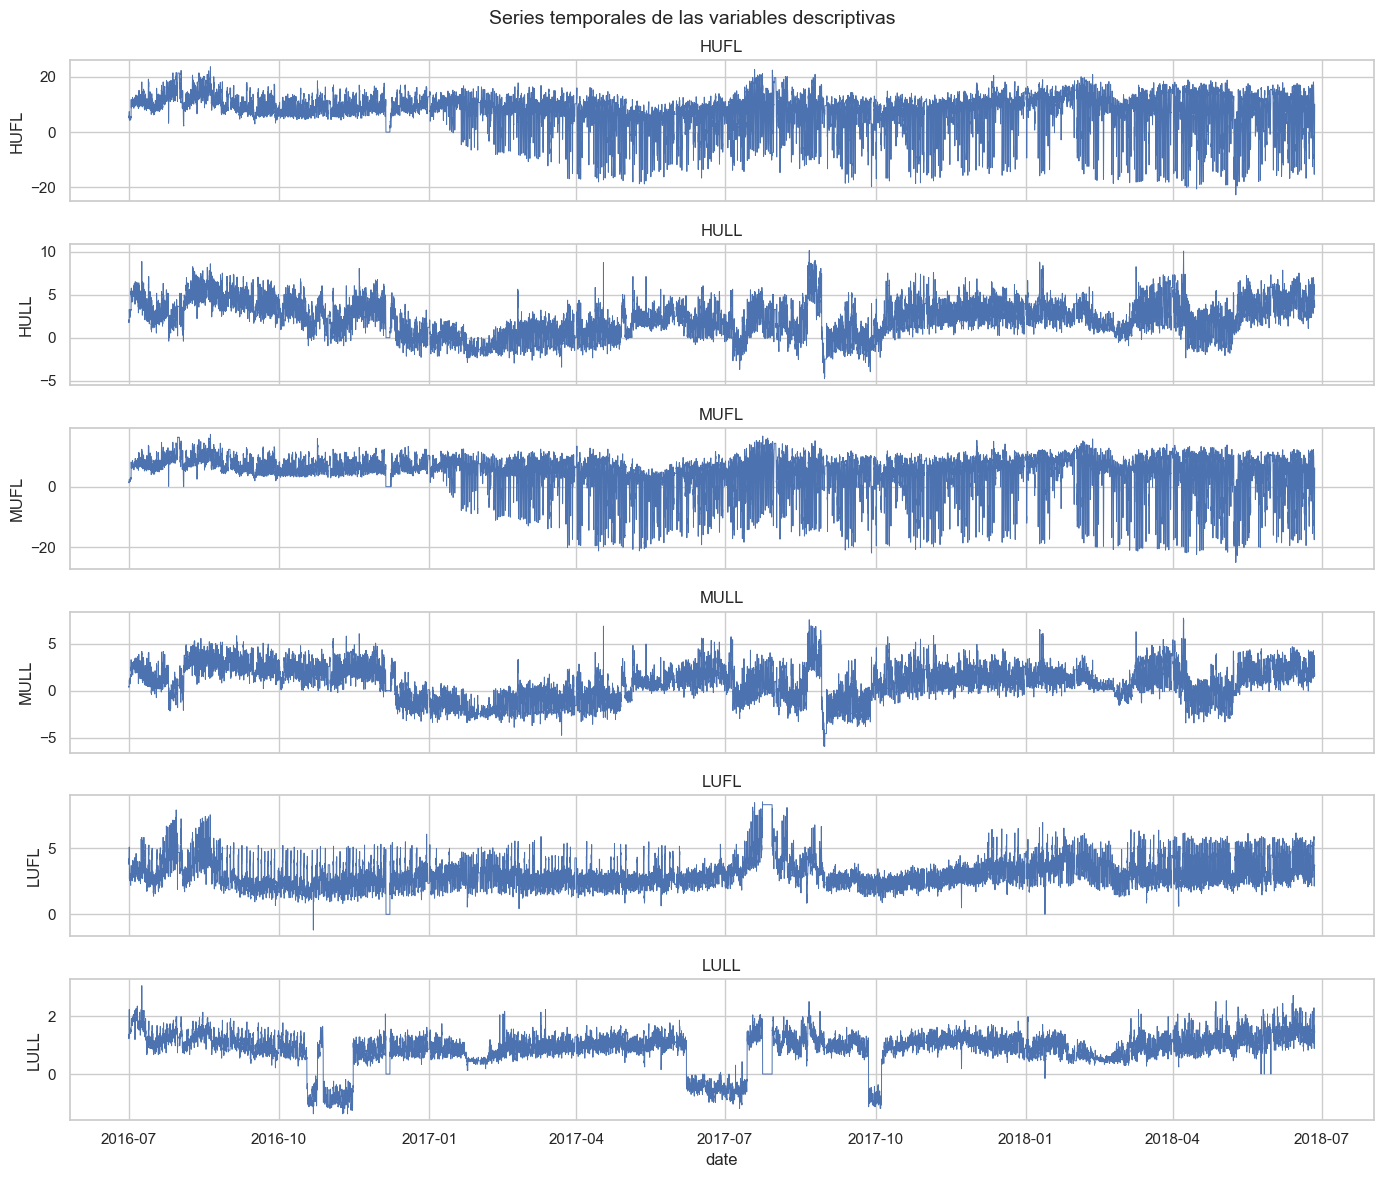

In [43]:
# Variables descriptivas (excluyendo la variable objetivo)
features = data.drop(columns=["OT"])

# SERIES TEMPORALES
fig, axes = plt.subplots(len(features.columns), 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(features.columns):
    sns.lineplot(x=features.index, y=features[col], ax=axes[i], linewidth=0.7)
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel(col)

plt.suptitle("Series temporales de las variables descriptivas", fontsize=14)
plt.tight_layout()

# Guardar figura
plt.savefig(r"..\images\series_temporales_variables_descriptivas.png", dpi=300, bbox_inches="tight")
plt.show()

#### B. Distribución de las variables

El análisis de los histogramas revela que las variables descriptivas presentan, en general, distribuciones no perfectamente normales, con distintos grados de asimetría y dispersión.

Variables como HUFL y MUFL muestran distribuciones más dispersas y con colas pronunciadas, lo que indica la presencia de valores extremos y una alta variabilidad en la carga.
Variables como HULL y MULL presentan distribuciones más centradas y relativamente simétricas, lo que sugiere un comportamiento más estable.
En el caso de LUFL y LULL, se observa una mayor concentración de valores en rangos específicos, junto con cierta asimetría, lo que podría reflejar distintos niveles operativos del sistema.

En conjunto, la presencia de colas largas y posibles valores atípicos indica que el sistema experimenta ocasionalmente condiciones extremas, que no deben considerarse errores, sino parte del comportamiento real del proceso.

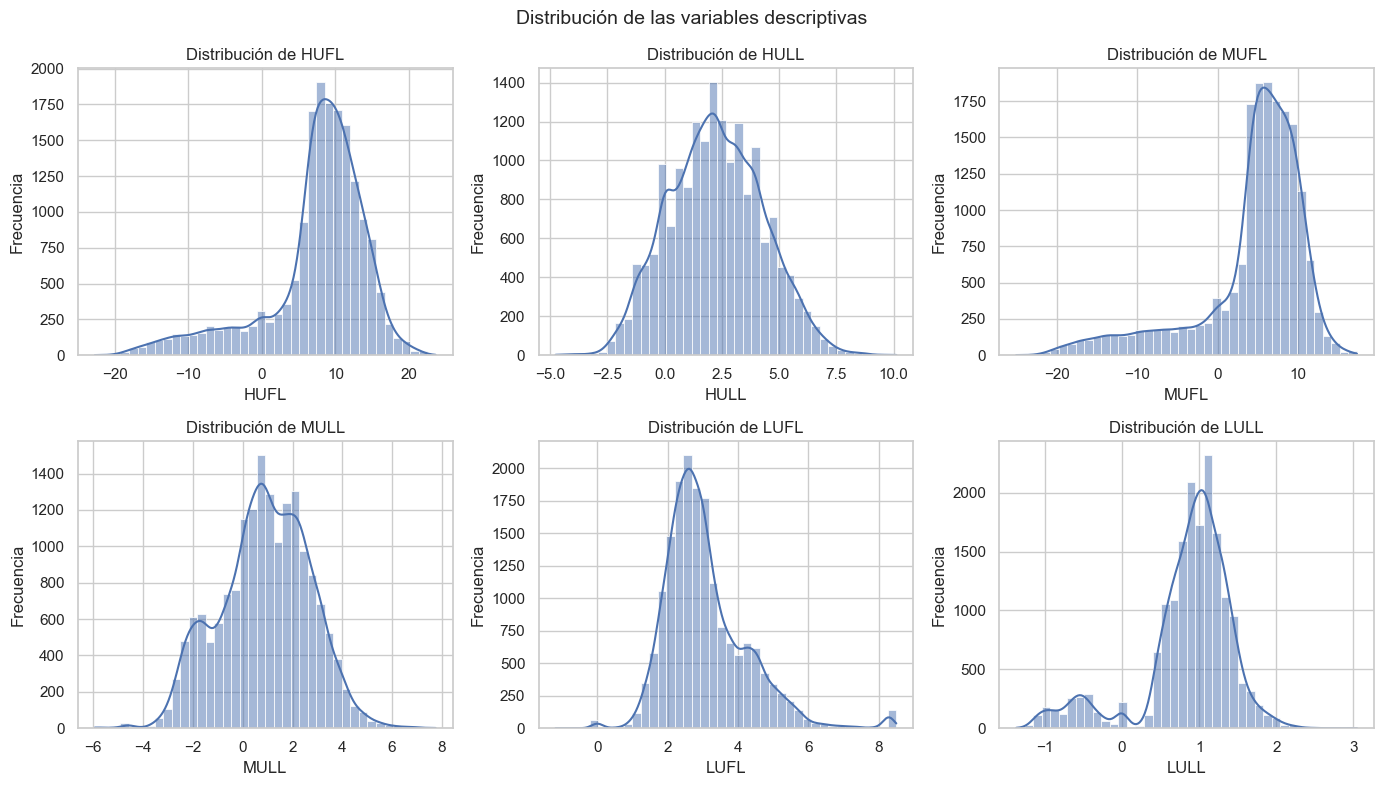

In [44]:
# DISTRIBUCIONES
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes = axes.flatten()

for i, col in enumerate(features.columns):
    sns.histplot(features[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución de las variables descriptivas", fontsize=14)
plt.tight_layout()

# Guardar figura
plt.savefig(r"..\images\histogramas_variables_descriptivas.png", dpi=300, bbox_inches="tight")

plt.show()

### 1.2.4. Correlación entre variables

Las variables operativas del transformador muestran relaciones coherentes con la naturaleza del sistema eléctrico, destacando **fuertes interdependencias entre variables de carga de un mismo nivel** y **comportamientos más independientes en relación con la temperatura del aceite (OT)**.

* **Correlaciones muy fuertes (|r| > 0.9):**  Las variables de carga en niveles similares están altamente correlacionadas entre sí (**HUFL–MUFL: 0.99**, **HULL–MULL: 0.93**). Esto indica una gran coherencia en la medición de la carga del transformador, donde distintas variables capturan prácticamente el mismo comportamiento operativo. Este resultado sugiere una clara **redundancia de información** dentro de estos grupos.

* **Correlaciones moderadas (0.3 < |r| < 0.7):**  Se observan relaciones moderadas entre variables de distintos niveles de carga, como **HULL–LULL: 0.38** y **LUFL–LULL: 0.34**. Estas correlaciones reflejan que, aunque las cargas en diferentes niveles están relacionadas, no evolucionan de forma completamente conjunta, aportando cierta diversidad en la información del sistema.

* **Correlaciones débiles (0.1 < |r| < 0.3):**  Algunas variables presentan relaciones débiles, como **HUFL–LUFL: 0.29**, **HULL–LUFL: 0.26** o **MUFL–LUFL: 0.18**, lo que sugiere que los distintos niveles de carga mantienen cierta independencia. En relación con la variable objetivo, las correlaciones más altas son **HULL–OT: 0.22** y **MULL–OT: 0.22**, indicando una relación positiva pero limitada entre la carga y la temperatura del aceite.

* **Correlaciones casi nulas (|r| < 0.1):**  La mayoría de las variables presentan correlaciones muy bajas con la variable objetivo (**HUFL–OT: 0.06**, **MUFL–OT: 0.05**, **LULL–OT: 0.07**), lo que indica que no existe una relación lineal directa significativa. Asimismo, algunas relaciones entre variables explicativas también son prácticamente inexistentes, reflejando comportamientos independientes dentro del sistema.

En resumen, las variables de carga muestran una **alta redundancia dentro de cada nivel (high, middle)**, mientras que la variable objetivo (*OT*) presenta **baja correlación lineal con todas ellas**, lo que sugiere que su comportamiento depende de relaciones más complejas. Desde el punto de vista del modelado, esto indica que modelos lineales podrían ser insuficientes, siendo más adecuado el uso de modelos capaces de capturar **dependencias temporales y no lineales**, como las redes neuronales recurrentes.

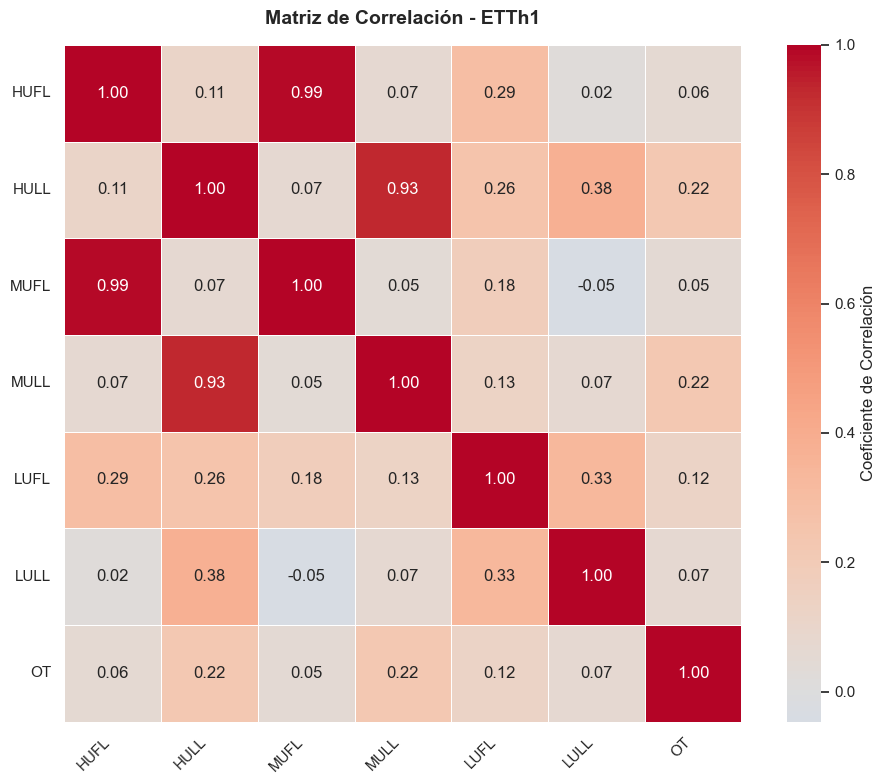

In [45]:
# Matriz de correlación
correlation_matrix = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  
            cmap='coolwarm',  
            center=0,  
            fmt='.2f',  
            square=True,  
            linewidths=0.5,  
            cbar_kws={'label': 'Coeficiente de Correlación'})

plt.title('Matriz de Correlación - ETTh1', 
          fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar si quieres
plt.savefig(r"..\images\correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# Top correlaciones
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
upper_triangle = correlation_matrix.where(mask)

correlations_flat = upper_triangle.stack().reset_index()
correlations_flat.columns = ['Variable 1', 'Variable 2', 'Correlación']
correlations_flat['Abs_Correlación'] = correlations_flat['Correlación'].abs()

top_correlations = correlations_flat.sort_values(
    'Abs_Correlación', ascending=False
).head(10)

print("Top 10 Correlaciones Más Fuertes:\n")

for _, row in top_correlations.iterrows():
    tipo = "Positiva" if row['Correlación'] > 0 else "Negativa"
    print(f"{row['Variable 1']:5s} <-> {row['Variable 2']:5s}: "
          f"{row['Correlación']:6.2f} ({tipo})")

Top 10 Correlaciones Más Fuertes:

HUFL  <-> MUFL :   0.99 (Positiva)
HULL  <-> MULL :   0.93 (Positiva)
HULL  <-> LULL :   0.38 (Positiva)
LUFL  <-> LULL :   0.33 (Positiva)
HUFL  <-> LUFL :   0.29 (Positiva)
HULL  <-> LUFL :   0.26 (Positiva)
HULL  <-> OT   :   0.22 (Positiva)
MULL  <-> OT   :   0.22 (Positiva)
MUFL  <-> LUFL :   0.18 (Positiva)
MULL  <-> LUFL :   0.13 (Positiva)


## 1.3. Preprocesado de los datos de entrada

En esta fase, transformaremos el dataframe original en estructuras que la `SimpleRNN` pueda procesar (tensores de 3 dimensiones: `[muestras, pasos_de_tiempo, características]`).

### 1.3.1. División del dataset (Train, Val, Test)

Dividimos de forma secuencial: 70% entrenamiento, 15% validación y 15% test.

> Hay que dividir ANTES de escalar. Si escalamos con todos los datos juntos, el modelo 've' información del futuro (*data leakage*). 

In [47]:
# Tamaños de las particiones
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

# División secuencial
train_df = data.iloc[:train_end]
val_df = data.iloc[train_end:val_end]
test_df = data.iloc[val_end:]

print(f"Tamaño total: {n}")
print(f"Entrenamiento: {len(train_df)} | Validación: {len(val_df)} | Test: {len(test_df)}")

Tamaño total: 17420
Entrenamiento: 12194 | Validación: 2613 | Test: 2613


### 1.3.2. Escalado de valores

Utilizaremos `MinMaxScaler` para llevar los valores al rango $[0, 1]$. 

> **Nota:** Ajustamos (`fit`) el escalador solo con los datos de **entrenamiento** y transformamos el resto con esos mismos parámetros.

In [48]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Ajustar solo con train y transformar todos
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# Guardamos el escalador de la variable objetivo (OT) para desescalar después
# OT es la última columna (índice -1)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_df[['OT']])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


### 1.3.3. Función para crear secuencias (Sliding Window)

Esta función (`create_sequences()`) recorrerá los datos usando una ventana deslizante. Si `window_size = 24` (un día completo en datos horarios), usaremos las filas de la 0 a la 23 para predecir el valor de la fila 24.

En mi caso voy a definir distintos tamaños de ventana a probar de 1 dia, 2 dias y 1 semana.

In [49]:
# Tamaños de ventana a probar
# 24h (1 día), 48h (2 días), 168h (1 semana)
WINDOW_SIZES = [24, 48, 168]

# Diccionario para guardar los datos de cada ventana
all_sequences = {}

# Bucle de preprocesamiento
for ws in WINDOW_SIZES:
    print(f"Generando secuencias para window_size = {ws}...")
    
    # Creamos las secuencias usando las funciones definidas antes
    X_train_ws, y_train_ws = create_sequences(train_scaled, ws)
    X_val_ws,   y_val_ws   = create_sequences(val_scaled,   ws)
    X_test_ws,  y_test_ws  = create_sequences(test_scaled,  ws)
    
    # Guardamos todo en el diccionario
    all_sequences[ws] = {
        'X_train': X_train_ws, 'y_train': y_train_ws,
        'X_val': X_val_ws,     'y_val': y_val_ws,
        'X_test': X_test_ws,   'y_test': y_test_ws
    }

    print(f" - X_train: {X_train_ws.shape} | y_train: {y_train_ws.shape}")
    print(f" - X_val:   {X_val_ws.shape}   | y_val: {y_val_ws.shape}\n")

Generando secuencias para window_size = 24...
 - X_train: (12170, 24, 7) | y_train: (12170,)
 - X_val:   (2589, 24, 7)   | y_val: (2589,)

Generando secuencias para window_size = 48...
 - X_train: (12146, 48, 7) | y_train: (12146,)
 - X_val:   (2565, 48, 7)   | y_val: (2565,)

Generando secuencias para window_size = 168...
 - X_train: (12026, 168, 7) | y_train: (12026,)
 - X_val:   (2445, 168, 7)   | y_val: (2445,)



## 1.4. Definición y Construcción del Modelo RNN

Una vez organizados los datos en el diccionario, se pone en marcha el bucle encargado de construir y entrenar los modelos de forma secuencial. Cada configuración se entrena de manera independiente y, para poder analizarlas posteriormente, los modelos resultantes se almacenan en el diccionario `trained_models`, mientras que sus historiales de entrenamiento se guardan en `trained_histories`.

Al revisar el `model.summary()` aparece un detalle especialmente interesante, y es que el número total de parámetros (4.673) es exactamente el mismo para los tres tamaños de ventana. Esto es debido a que en una RNN, los pesos no dependen de la longitud de la secuencia de entrada, sino que se **comparten a lo largo de todos los pasos temporales**. Es decir, la red utiliza la misma 'memoria' para procesar cada instante, independientemente de si la ventana abarca 24, 48 o 168 horas. Por eso, ampliar la ventana no incrementa el número de parámetros.

Si se desglosa el cálculo, se entiende mejor.
* La capa SimpleRNN con 64 unidades concentra la mayor parte de los parámetros, combinando los pesos de entrada (7 × 64), los pesos recurrentes (64 × 64) y los sesgos, lo que suma 4.608 parámetros. 
* A esto se añade la capa densa final, que conecta las 64 salidas de la RNN con una única neurona, aportando 65 parámetros adicionales. 
* El resultado total es, por tanto, 4.673 parámetros, idéntico en todos los modelos al no depender del tamaño de la ventana temporal.


> Para garantizar que los resultados sean consistentes cada vez que se ejecute la celda, invocamos las semillas antes de la creación del modelo.

In [50]:
# Hiperparámetros
SEED = 42
UNITS = 64 # Si el modelo sobreentrena lo bajo a 32 o añado una capa de Dropout(0.2)
BATCH = 64  # Si el entrenamiento va muy lento lo subo
EPOCHS = 200
PATIENCE = 10 # Si se queda en un mínimo local lo subo
N_FEATURES = train_scaled.shape[1] # En este caso, 7 variables

In [ ]:
import pickle

# --- CONFIGURACIÓN DE PERSISTENCIA ---
save_dir = r"..\modelos_SimpleRNN"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Guardar modelos e historiales de entrenamiento
trained_models = {}
trained_histories = {}

# Bucle de Entrenamiento y Evaluación
for ws in WINDOW_SIZES:
    print(f"\n{'='*60}")
    print(f" CONFIGURANDO MODELO PARA WINDOW_SIZE = {ws}")
    print(f"{'='*60}")
   
    # Resetear semillas para reproducibilidad
    np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# --- Definición del Modelo SimpleRNN ---
    model = Sequential([
        Input(shape=(ws, N_FEATURES)),
        SimpleRNN(UNITS, activation="tanh"), 
        Dense(1) # la temperatura OT
    ])

    model.compile(optimizer="adam", loss="mean_squared_error")

    # Mostrar arquitectura
    print(f"\nResumen del modelo (ws={ws}):")
    model.summary()

# --- Entrenamiento con EarlyStopping ---
    # Si la val_loss no mejora en 5 épocas, para y recupera el mejor peso
    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

    history = model.fit(
            all_sequences[ws]['X_train'], all_sequences[ws]['y_train'],
            validation_data=(all_sequences[ws]['X_val'], all_sequences[ws]['y_val']),
            epochs=EPOCHS, 
            batch_size=BATCH, 
            callbacks=[early_stop], 
            verbose=1
        )
    
    # --- GUARDADO DISRUPTIVO ---
    # 1. Guardar el modelo en formato nativo de Keras
    model_filename = f"{save_dir}/modelo_rnn_ws_{ws}.keras"
    model.save(model_filename)
    
    # 2. Guardar el historial (history.history es un dict) para no perder las gráficas
    history_filename = f"{save_dir}/historia_ws_{ws}.pkl"
    with open(history_filename, 'wb') as f:
        pickle.dump(history.history, f)
        
    print(f"\nModelo y historial guardados para ws={ws} en {save_dir}/")   
    # Guardamos los objetos para los siguientes lotes
    trained_models[ws] = model
    trained_histories[ws] = history


 CONFIGURANDO MODELO PARA WINDOW_SIZE = 24

Resumen del modelo (ws=24):


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0059 - val_loss: 5.9672e-04
Epoch 2/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.5527e-04 - val_loss: 3.4489e-04
Epoch 3/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.0963e-04 - val_loss: 3.0651e-04
Epoch 4/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.6111e-04 - val_loss: 2.5464e-04
Epoch 5/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8163e-04 - val_loss: 2.2397e-04
Epoch 6/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2448e-04 - val_loss: 2.0747e-04
Epoch 7/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8225e-04 - val_loss: 2.0099e-04
Epoch 8/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.5121e-04 - val_loss: 1.9208e-04
Epoch 9/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2933e-04 - val_loss: 1.7947e-04
Epoch 10/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1414e-04 - val_loss: 1.7673e-04
Epoch 11/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0059 - val_loss: 6.3663e-04
Epoch 2/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.0940e-04 - val_loss: 3.2464e-04
Epoch 3/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.0614e-04 - val_loss: 2.7068e-04
Epoch 4/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5022e-04 - val_loss: 2.3955e-04
Epoch 5/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8637e-04 - val_loss: 2.2428e-04
Epoch 6/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3806e-04 - val_loss: 2.1657e-04
Epoch 7/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0153e-04 - val_loss: 2.1287e-04
Epoch 8/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7342e-04 - val_loss: 2.1147e-04
Epoch 9/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.5150e-04 - val_loss: 2.1145e-04
Epoch 10/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.3428e-04 - val_loss: 2.1226e-04
Epoch 11/200
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0059 - val_loss: 4.8463e-04
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 9.0751e-04 - val_loss: 3.4651e-04
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 7.6312e-04 - val_loss: 2.8592e-04
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 6.9113e-04 - val_loss: 2.4577e-04
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 6.1580e-04 - val_loss: 2.3357e-04
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.8101e-04 - val_loss: 2.6440e-04
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.5851e-04 - val_loss: 2.7217e-04
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5.3688e-04 - val_loss: 2.7003e-04
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5.1857e-04 - val_loss: 2.6437e-04
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5.0353e-04 - val_loss: 2.5767e-04
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3

## 1.5. Análisis de Resultados y Comportamiento del Modelo

El análisis de las métricas consolidadas confirma que **la ventana de 24 horas es la configuración óptima para este problema**. Al utilizar un horizonte temporal de un día, el modelo logra el mejor equilibrio entre ajuste y generalización, alcanzando un **MAE de 0.4800** y un **MSE de 0.4761** en el conjunto de test. Estos valores indican que la información más relevante para predecir la temperatura del aceite se encuentra en el ciclo diario inmediato, permitiendo que la red capture los patrones térmicos con una precisión inferior a medio grado Celsius.

A medida que el tamaño de la ventana se amplía a 48 y 168 horas, el rendimiento del sistema experimenta una degradación progresiva. El **RMSE aumenta de 0.69 a 0.89**, lo que demuestra que proporcionar una semana completa de historial no beneficia a esta arquitectura específica. En lugar de aprender tendencias estacionales de largo plazo, el modelo parece verse perjudicado por la complejidad adicional, sugiriendo que para una SimpleRNN, el exceso de datos en la secuencia de entrada actúa más como ruido que como información útil una vez superado el umbral de las 24 horas.

Esta pérdida de eficiencia en secuencias largas es un síntoma clásico del desvanecimiento del gradiente (*vanishing gradient*), una limitación técnica fundamental de las SimpleRNN. Debido a que la red procesa la información paso a paso, la influencia matemática de los primeros datos de una ventana de 168 pasos se diluye casi por completo antes de llegar a la predicción final. El modelo termina 'olvidando' lo que ocurrió al inicio de la semana, lo que explica por qué no puede mejorar los resultados de la ventana más corta.

Finalmente, resulta notable que el **RMSE de entrenamiento (1.04) sea superior al de test (0.69)**. La explicación podría residir en que el tramo final del dataset (usado para el test) presenta una dinámica más estable y menos volátil que el periodo inicial de entrenamiento. Esto permite que la red aplique la lógica aprendida con mayor éxito sobre datos menos ruidosos.

In [ ]:
results_list = []

for ws in WINDOW_SIZES:
    model = trained_models[ws]
    data = all_sequences[ws]
    
    # Diccionario para iterar sobre los conjuntos
    subconjuntos = {
        'Entrenamiento': (data['X_train'], data['y_train']),
        'Validación': (data['X_val'], data['y_val']),
        'Test': (data['X_test'], data['y_test'])
    }
    
    for nombre, (X, y_real_scaled) in subconjuntos.items():
        # Predicción
        y_pred_scaled = model.predict(X, verbose=0)
        
        # Desescalado a valores reales (°C)
        y_pred = target_scaler.inverse_transform(y_pred_scaled)
        y_real = target_scaler.inverse_transform(y_real_scaled.reshape(-1, 1))
        
        # Cálculo de métricas
        rmse = root_mean_squared_error(y_real, y_pred)
        mae = mean_absolute_error(y_real, y_pred)
        mse = mean_squared_error(y_real, y_pred) 
        
        results_list.append({
            "Window Size": ws,
            "Conjunto": nombre,
            "MSE": round(mse, 4),
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4),

        })

# Generación de la tabla comparativa final
df_resultados = pd.DataFrame(results_list)
print("\nTABLA COMPARATIVA DE RESULTADOS:")
print(df_resultados.to_string(index=False))

# Ruta donde quieres guardar el archivo
ruta_excel = r'..\modelos_SimpleRNN\resultados_modelos.xlsx'

# Guardar en Excel
with pd.ExcelWriter(ruta_excel, engine='openpyxl', mode='w') as writer:
    df_resultados.to_excel(writer, sheet_name='SimpleRNN', index=False)


TABLA COMPARATIVA DE RESULTADOS:
 Window Size      Conjunto  MSE  RMSE  MAE
          24 Entrenamiento 0.95  0.97 0.67
          24    Validación 0.36  0.60 0.44
          24          Test 0.43  0.66 0.46
          48 Entrenamiento 1.09  1.04 0.74
          48    Validación 0.53  0.73 0.56
          48          Test 0.57  0.76 0.54
         168 Entrenamiento 0.94  0.97 0.67
         168    Validación 0.38  0.62 0.45
         168          Test 0.42  0.65 0.45


## 1.6. Visualización de Loss y Predicciones

Continuamos centrandonos en dos aspectos fundamentales: 1) las curvas de aprendizaje (*loss*); y 2) la comparación visual entre los valores reales y las predicciones en el conjunto de test.

Dado que el conjunto de test abarca unas 2613 horas, representar todos los puntos en un único gráfico provoca que las líneas (la azul para los valores reales y la roja para las predicciones) se superpongan hasta formar una especie de 'mancha' de color. Esta densidad dificulta distinguir con precisión el grado de acierto del modelo, ya que los errores quedan visualmente diluidos.

En cuanto a las **curvas de *loss***, se observa un comportamiento claro y consistente. Tanto el error de entrenamiento como el de validación descienden con rapidez en las primeras épocas y después se estabilizan. Este patrón indica que el mecanismo de *EarlyStopping* ha actuado correctamente, deteniendo el entrenamiento en el momento adecuado. Además, la convergencia es suave y sin oscilaciones bruscas, lo que sugiere que el ratio de aprendizaje del optimizador Adam está bien ajustado al problema.

Por otro lado, la vista completa de **real vs. predicho** permite evaluar el comportamiento global del modelo. A pesar de la saturación visual, se aprecia que la red logra capturar la tendencia general de la serie. De hecho, la red identifica correctamente los periodos de subida y bajada sostenida de la temperatura. Sin embargo, el modelo tiende a suavizar la señal, comportándose de forma similar a una media móvil, lo que le impide alcanzar con precisión los valores más extremos.

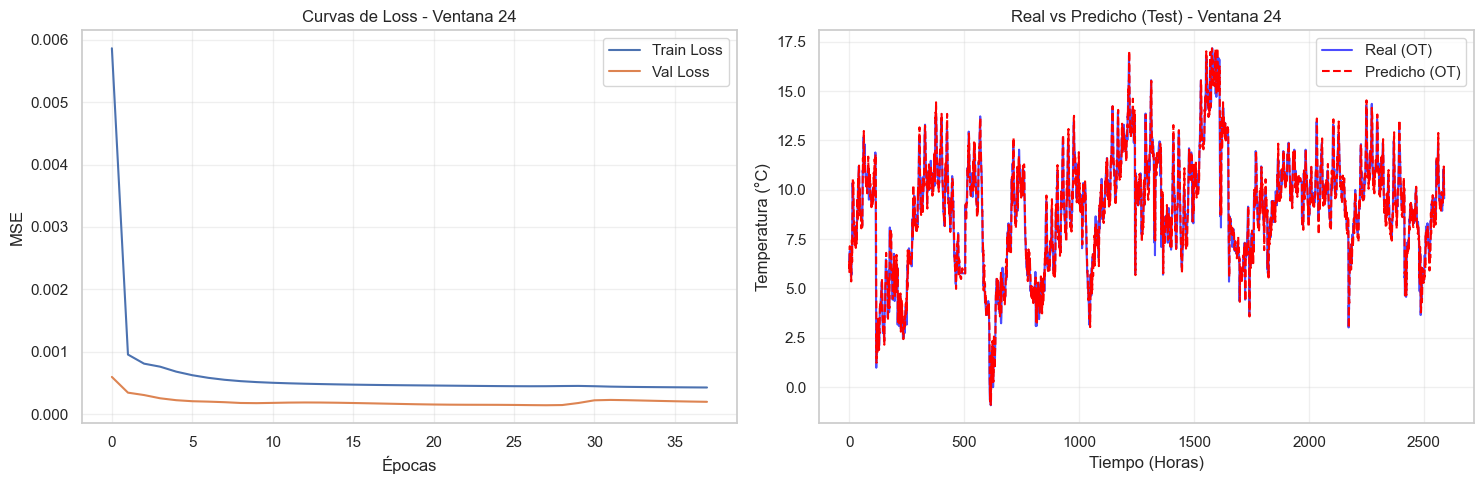

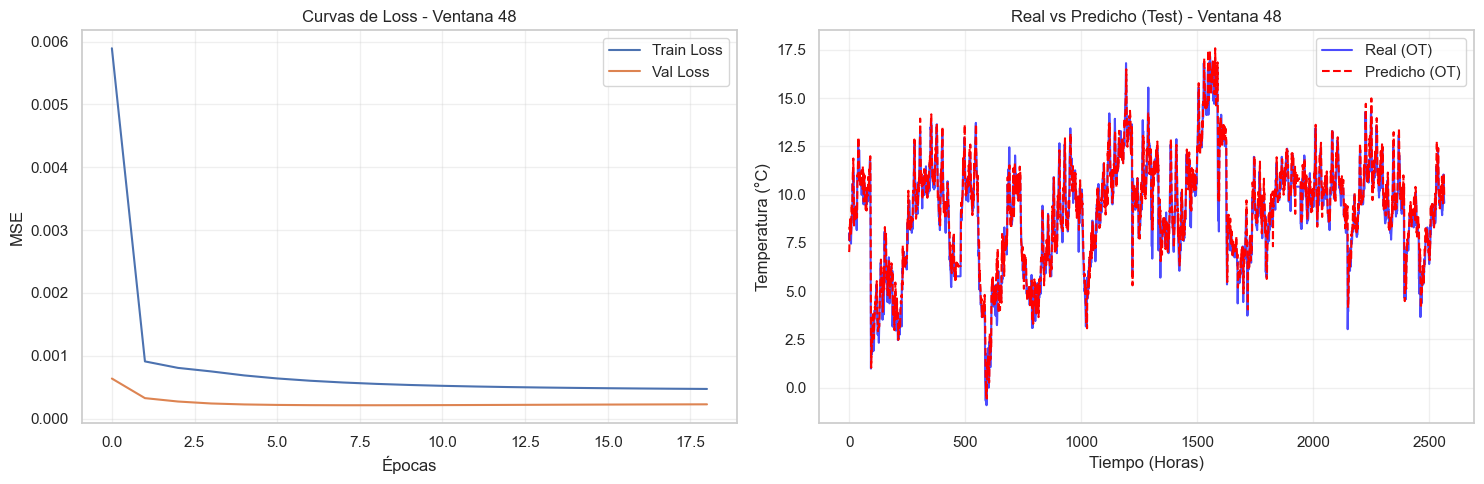

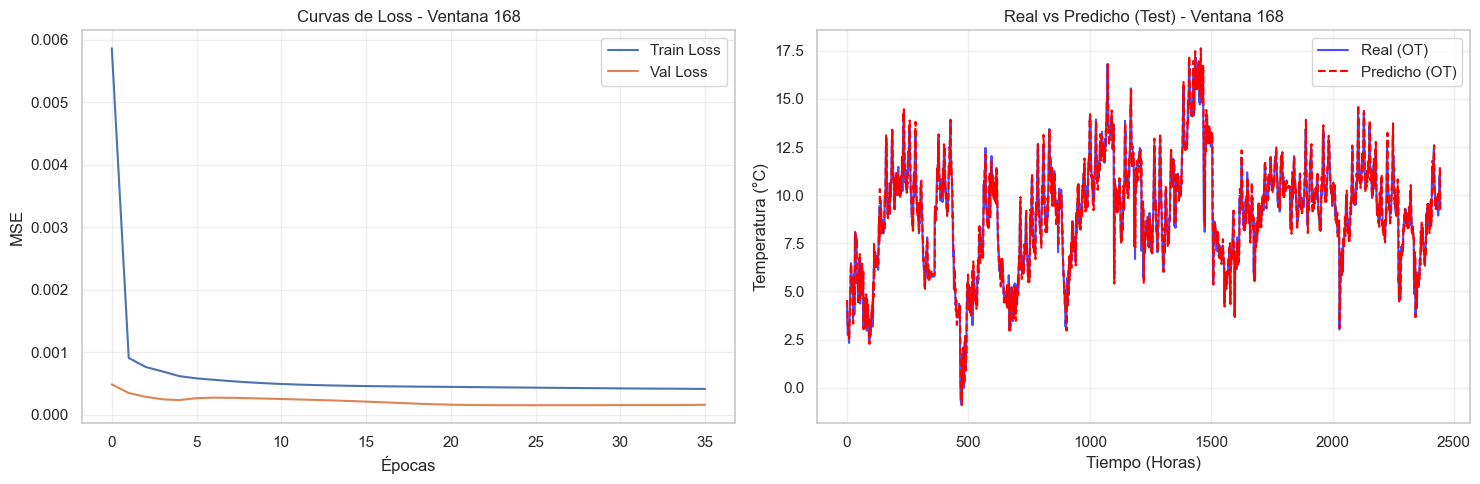

In [ ]:
# Bucle de visualización de resultados
for ws in WINDOW_SIZES:
    history = trained_histories[ws]
    model = trained_models[ws]
    data = all_sequences[ws]
    
    # Preparar datos de Test para la gráfica
    y_test_pred = target_scaler.inverse_transform(model.predict(data['X_test'], verbose=0))
    y_test_real = target_scaler.inverse_transform(data['y_test'].reshape(-1, 1))

    plt.figure(figsize=(15, 5))

    # --- Gráfica de Loss (MSE) ---
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Curvas de Loss - Ventana {ws}')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Gráfica Real vs Predicho ---
    plt.subplot(1, 2, 2)
    plt.plot(y_test_real, label='Real (OT)', color='blue', alpha=0.7)
    plt.plot(y_test_pred, label='Predicho (OT)', color='red', linestyle='--')
    plt.title(f'Real vs Predicho (Test) - Ventana {ws}')
    plt.xlabel('Tiempo (Horas)')
    plt.ylabel('Temperatura (°C)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(f"../images/SimpleRNN_WindowSize_{ws}.png", dpi=300, bbox_inches="tight")
    plt.show()

Al acercarnos a las primeras 200 horas (aproximadamente ocho días y medio) la visualización deja de ser una panorámica general y empieza a revelar matices clave del comportamiento del modelo. En este tramo más corto es posible observar con mayor claridad cómo responde la predicción frente a la realidad.

Uno de los aspectos más evidentes es el **retraso (*lag*)**. La línea predicha parece reaccionar con cierto desfase respecto a la real, como si fuera siempre un paso por detrás. Este patrón sugiere que el modelo tiende a apoyarse excesivamente en el valor inmediatamente anterior, asumiendo que el siguiente será muy similar.

También se aprecia mejor la **precisión en los picos**. En lugar de alcanzar los máximos y mínimos reales, el modelo tiende a suavizarlos. Esto indica una dificultad para capturar cambios bruscos.

Por último, este zoom permite identificar claramente el **ciclo diario**. En 200 horas se observan varias oscilaciones completas de subida y bajada, lo que facilita comprobar si el modelo ha aprendido correctamente el patrón día-noche. Aunque logra reproducir la forma general de estas variaciones, los desfases y la pérdida de intensidad en los picos revelan que aún no capta del todo la dinámica completa del sistema.

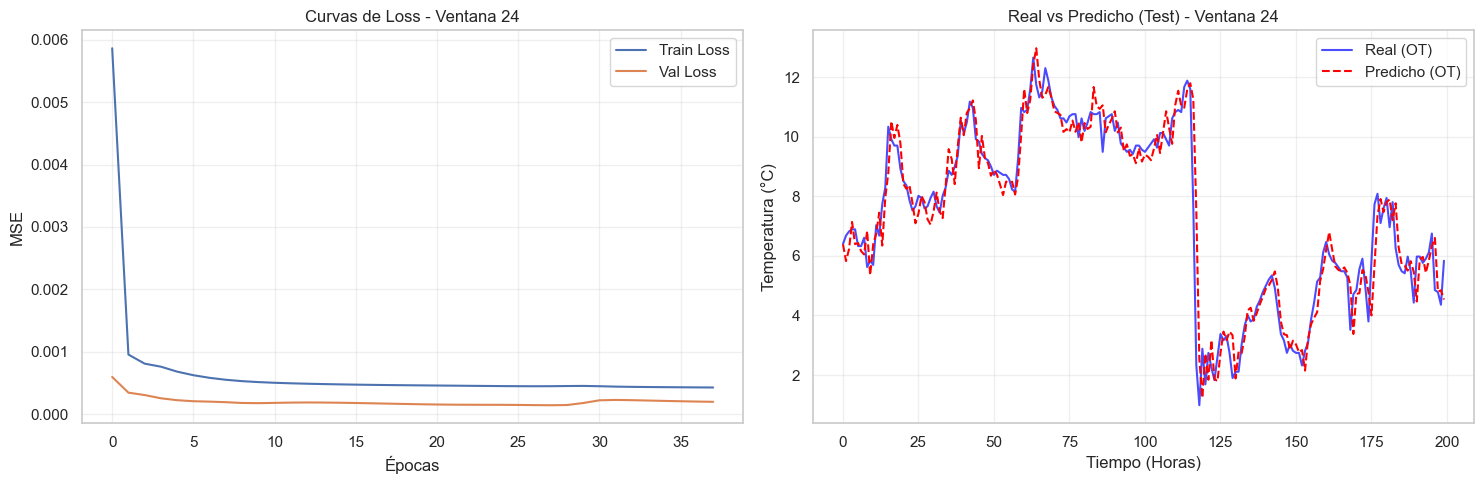

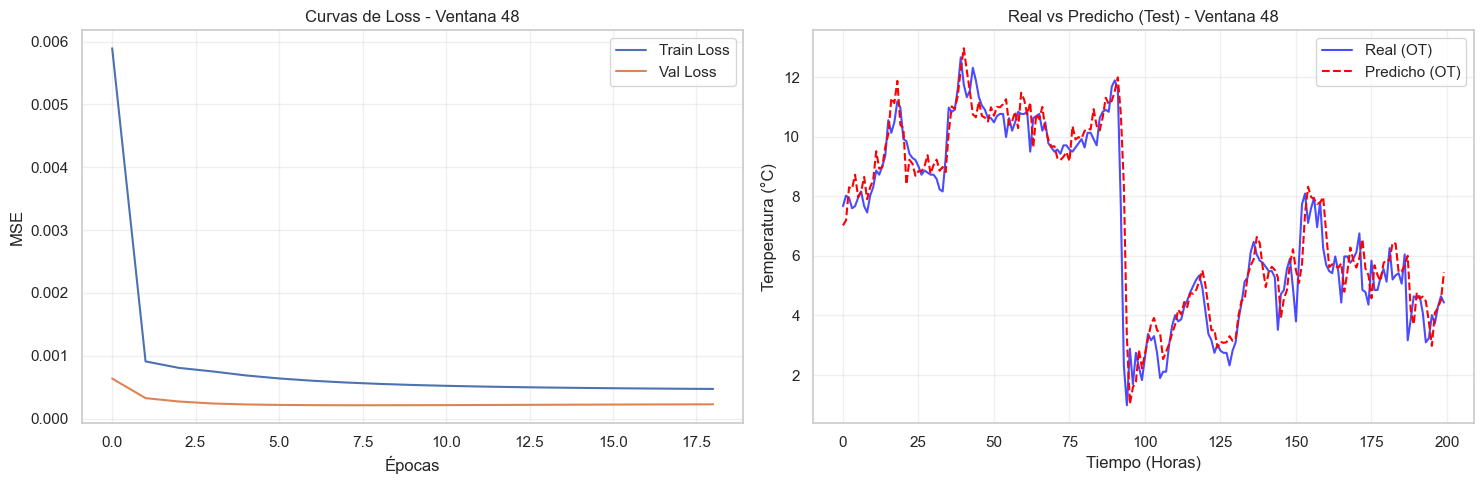

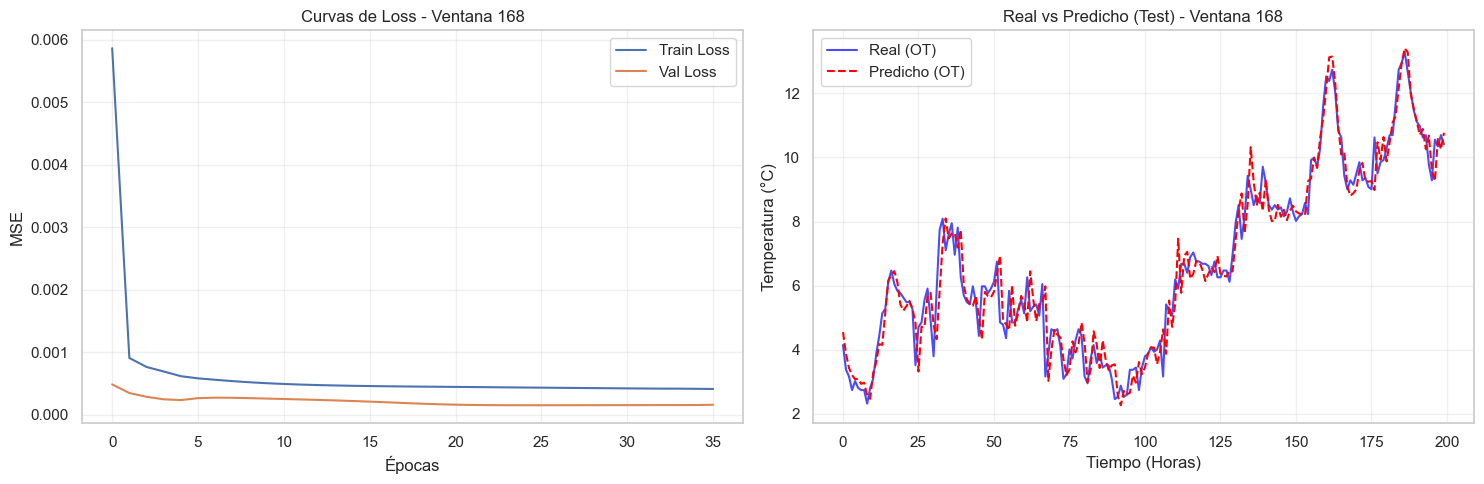

In [ ]:
# Bucle de visualización de resultados
for ws in WINDOW_SIZES:
    history = trained_histories[ws]
    model = trained_models[ws]
    data = all_sequences[ws]
    
    # Preparar datos de Test para la gráfica
    y_test_pred = target_scaler.inverse_transform(model.predict(data['X_test'], verbose=0))
    y_test_real = target_scaler.inverse_transform(data['y_test'].reshape(-1, 1))

    plt.figure(figsize=(15, 5))

    # --- Gráfica de Loss (MSE) ---
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Curvas de Loss - Ventana {ws}')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Gráfica Real vs Predicho (primeras 200 horas del Test)---
    plt.subplot(1, 2, 2)
    plt.plot(y_test_real[:200], label='Real (OT)', color='blue', alpha=0.7)
    plt.plot(y_test_pred[:200], label='Predicho (OT)', color='red', linestyle='--')
    plt.title(f'Real vs Predicho (Test) - Ventana {ws}')
    plt.xlabel('Tiempo (Horas)')
    plt.ylabel('Temperatura (°C)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(f"../images/SimpleRNN_WindowSize_{ws}_subsample200.png", dpi=300, bbox_inches="tight")
    plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> 

<strong>¿Por qué deben convertirse los datos en ventanas deslizantes?</strong>

Las series temporales son flujos de datos continuos sin etiquetas explícitas. Sin embargo, las redes neuronales requieren una estructura de aprendizaje supervisado para poder entrenarse. En este sentido, la técnica de ventana deslizante (*sliding window*) es esencial porque:
* <strong>Crea pares de entrada-salida (X -> y):</strong> Transforma una secuencia plana en ejemplos discretos donde el pasado reciente actúa como características (*features*) y el valor siguiente como la etiqueta (*target*).
* <strong>Define un tamaño de entrada fijo:</strong> Las arquitecturas como la SimpleRNN necesitan que el vector de entrada tenga una dimensión predefinida para procesar la información.
* <strong>Estructura la dependencia temporal:</strong> Permite que el modelo aprenda de forma sistemática cómo los patrones observados en un intervalo de tiempo específico (por ejemplo, 24 horas) se correlacionan con el resultado inmediato posterior.

<strong>¿Qué limitaciones tiene una SimpleRNN para secuencias largas?</strong>

La principal limitación de la SimpleRNN es el fenómeno conocido como desvanecimiento del gradiente (*vanishing gradient*).

Este problema ocurre por lo siguiente:

* <strong>Propagación del error:</strong> Durante el entrenamiento, el error se propaga hacia atrás en el tiempo a través de cada paso de la secuencia. En ventanas largas (como la de 168h), los gradientes se multiplican repetidamente por los pesos de la red.
* <strong>Pérdida de información:</strong> Si esos pesos son pequeños, el gradiente disminuye exponencialmente hasta volverse insignificante. Como resultado, los pesos de las primeras etapas de la ventana no se actualizan eficazmente.
* <strong>'Olvido' a largo plazo:</strong> En la práctica, esto significa que la red pierde la capacidad de aprender dependencias lejanas. De modo que el modelo solo "recuerda" y reacciona a los eventos más recientes de la secuencia, ignorando patrones importantes que ocurrieron al inicio de la ventana.

Para mitigar esto, se desarrollaron arquitecturas más complejas como **LSTM (Long Short-Term Memory)** y **GRU (Gated Recurrent Unit)**, que utilizan 'puertas' lógicas para decidir qué información preservar y cuál descartar a lo largo del tiempo.
</p>
</div>

# 2. Problema de predicción multivariante

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2 pts.].** Entrena modelos recurrentes avanzados para predicción multivariante de series temporales y compara su rendimiento. Para ello:
- Usa el mismo dataset y preprocesamiento que en el ejercicio anterior.

- Implementa y compara los dos modelos siguientes:
    - Un modelo con una capa `LSTM`, una capa `Dropout` y una capa de salida `Dense`.
    - Un modelo con una capa `GRU`, una capa `Dropout` y una capa de salida `Dense`.
    - Compila ambos modelos con loss `mean_squared_error` y optimizador `Adam`.
    - Usa semillas aleatorias para mantener la reproducibilidad.
    - Usa el mismo número de neuronas, tamaño de batch y epochs que en el ejercicio anterior.

- Añade callbacks durante el entrenamiento:
    - EarlyStopping para detener el entrenamiento si no mejora la validación.
    - ReduceLROnPlateau para reducir el learning rate cuando la validación se estanque.

- Entrena ambos modelos y calcula RMSE y MAE en entrenamiento, validación y test.
- Añade los resultados a la tabla comparativa creada en el ejercicio anterior.
- Visualiza las curvas de loss por epoch y los valores reales vs. valores predichos.
- Realiza un breve análisis de la comparación de resultados entre SimpleRNN, LSTM y GRU. Indica si se aprecia overfitting en algún modelo.

## 2.1. Modelos Recurrentes Avanzados (LSTM y GRU)

Como se ha comentado en el apartado de Solución del ejercicio 1, las redes LSTM y GRU fueron diseñadas para solucionar el problema del desvanecimiento del gradiente que observamos en la SimpleRNN. Utilizan mecanismos de 'puertas' para decidir qué información fluye a través del tiempo, permitiendo capturar dependencias mucho más largas y complejas.

### 2.1.1. Configuración de Callbacks y Parámetros

En este apartado además de ustilizar `EarlyStopping`, añadimos `ReduceLROnPlateau`, que actuará como un 'acelerador inteligente', reduciendo la tasa de aprendizaje si el modelo deja de mejorar para intentar encontrar un mínimo global más preciso.

In [ ]:
# Parámetros heredados del Ejercicio 1
WS_BEST = 24  # Usamos la mejor ventana del ejercicio anterior

# Definición de Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

# Recuperamos los datos del diccionario all_sequences
X_train_2 = all_sequences[WS_BEST]['X_train']
y_train_2 = all_sequences[WS_BEST]['y_train']
X_val_2   = all_sequences[WS_BEST]['X_val']
y_val_2   = all_sequences[WS_BEST]['y_val']
X_test_2  = all_sequences[WS_BEST]['X_test']
y_test_2  = all_sequences[WS_BEST]['y_test']

## 2.2. Definición y Construcción de Modelos LSTM y GRU

El bucle de entrenamiento para los modelos avanzados sigue una estructura similar a la utilizada en el primer ejercicio, garantizando que ambos se evalúen bajo las mismas condiciones (mismo tamaño de ventana de 24 horas y mismas semillas aleatorias). Sin embargo, al observar los resúmenes (`model.summary()`) de las nuevas arquitecturas, la diferencia de complejidad estructural frente a la SimpleRNN se hace evidente de inmediato.

El número de parámetros entrenables experimenta un aumento drástico, reflejando el complejo mecanismo interno que utilizan estas redes para combatir el desvanecimiento del gradiente:

* **El Modelo LSTM:** Presenta un total de **18.497 parámetros**. Esta cifra cuadruplica aproximadamente los de la SimpleRNN ($4.673$). La razón técnica es que una celda LSTM no es una simple función de activación, sino que contiene cuatro redes neuronales interactuando internamente (tres "puertas" (olvido, entrada y salida) y un estado de celda candidato). Al desglosarlo, la capa LSTM requiere calcular cuatro conjuntos de pesos para las $7$ variables de entrada y las $64$ unidades ocultas, generando $18.432$ parámetros, a los que se suma la capa densa de salida ($65$).
* **El Modelo GRU:** Resulta ser una versión ligeramente más eficiente, con **14.081 parámetros**. La arquitectura GRU fue diseñada para simplificar la LSTM combinando las puertas de olvido y entrada en una sola "puerta de actualización" y fusionando los estados ocultos. Al tener internamente tres operaciones matemáticas en lugar de cuatro, requiere menos pesos ($14.016$ en la capa recurrente), lo que teóricamente debería traducirse en un entrenamiento más rápido manteniendo un rendimiento competitivo.

> **Nota sobre la Regularización:** En ambos modelos, la inclusión de la capa `Dropout(0.2)` añade $0$ parámetros entrenables, ya que su única función es "apagar" aleatoriamente el $20\%$ de las conexiones durante el entrenamiento. Esta técnica es fundamental en modelos con tanta capacidad (especialmente en la LSTM) para forzar a la red a no memorizar patrones específicos y evitar el sobreajuste.

Finalmente, el comportamiento dinámico del entrenamiento también ha cambiado. Los registros muestran cómo el *callback* `ReduceLROnPlateau` intervino repetidas veces en ambos modelos, reduciendo el *learning rate* a la mitad (hasta llegar a órdenes de magnitud de $10^{-5}$) al detectar estancamientos en el error de validación, permitiendo un ajuste fino ("*fine-tuning*") que el optimizador Adam por defecto no habría logrado por sí solo.

In [ ]:
# (Asegúrate de tener montado Drive como hicimos antes)
save_dir_adv = "..\LSTM_y_GRU"
if not os.path.exists(save_dir_adv):
    os.makedirs(save_dir_adv)

model_types = ['LSTM', 'GRU']
trained_models_adv = {}
trained_histories_adv = {}

for m_type in model_types:
    print(f"\n{'='*60}\n ENTRENANDO MODELO: {m_type}\n{'='*60}")
    
    # Semillas para reproducibilidad
    np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
    
    # Definición de arquitectura según el tipo
    model = Sequential()
    model.add(Input(shape=(WS_BEST, N_FEATURES)))
    
    if m_type == 'LSTM':
        model.add(LSTM(UNITS, activation="tanh"))
    else:
        model.add(GRU(UNITS, activation="tanh"))
        
    model.add(Dropout(0.2)) # Capa para prevenir overfitting
    model.add(Dense(1))
    
    model.compile(optimizer="adam", loss="mean_squared_error")
    model.summary()
    
    # Entrenamiento
    history = model.fit(
        X_train_2, y_train_2,
        validation_data=(X_val_2, y_val_2),
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    trained_models_adv[m_type] = model
    trained_histories_adv[m_type] = history

     # --- GUARDADO DISRUPTIVO ---
    model_filename = f"{save_dir_adv}/modelo_{m_type}_ws_{WS_BEST}.keras"
    model.save(model_filename)

    history_filename = f"{save_dir_adv}/historia_{m_type}_ws_{WS_BEST}.pkl"
    with open(history_filename, 'wb') as f:
        pickle.dump(history.history, f)

    trained_models_adv[m_type] = model
    trained_histories_adv[m_type] = history


 ENTRENANDO MODELO: LSTM


<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
C:\Users\jubeda2\AppData\Local\Temp\ipykernel_18368\4280514625.py:2: SyntaxWarning: invalid escape sequence '\L'
  save_dir_adv = "..\LSTM_y_GRU"


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0049 - val_loss: 6.1717e-04 - learning_rate: 0.0010
Epoch 2/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0021 - val_loss: 4.8428e-04 - learning_rate: 0.0010
Epoch 3/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 3.5835e-04 - learning_rate: 0.0010
Epoch 4/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0016 - val_loss: 3.3052e-04 - learning_rate: 0.0010
Epoch 5/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_loss: 3.2143e-04 - learning_rate: 0.0010
Epoch 6/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0013 - val_loss: 2.3125e-04 - learning_rate: 0.0010
Epoch 7/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0012 - val_loss: 3.4525e-04 - learning_rate: 0.0010
Epoch 8/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0011 - val_loss: 3.1629e-04 - learning_rate: 0.0010
Epoch 9/200
186/191 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011
Epoch 9: Red

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 14,081 (55.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0082 - val_loss: 2.9008e-04 - learning_rate: 0.0010
Epoch 2/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 5.2424e-04 - learning_rate: 0.0010
Epoch 3/200
185/191 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0018
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0017 - val_loss: 3.1573e-04 - learning_rate: 0.0010
Epoch 4/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0015 - val_loss: 2.6756e-04 - learning_rate: 5.0000e-04
Epoch 5/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0015 - val_loss: 1.7422e-04 - learning_rate: 5.0000e-04
Epoch 6/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0014 - val_loss: 1.7428e-04 - learning_rate: 5.0000e-04
Epoch 7/200
191/191 ━━━━━━━━━━━━━━

## 2.3. Análisis Comparativo: SimpleRNN vs. Modelos Avanzados

Tras consolidar las métricas en la tabla final, los resultados revelan un comportamiento contraintuitivo pero profundamente revelador sobre la naturaleza de las redes neuronales recurrentes en la práctica. Contrario a la expectativa teórica general, **el modelo SimpleRNN con ventana de 24 horas sigue siendo el que mejor rendimiento ofrece**, superando a la arquitectura LSTM y manteniéndose a la par con la GRU.

Este fenómeno no indica un error en el entrenamiento, sino que responde a tres factores arquitectónicos y de regularización clave:

1. **La longitud de la secuencia temporal:** Las arquitecturas LSTM y GRU fueron diseñadas específicamente para resolver el desvanecimiento del gradiente en secuencias largas (dependencias a largo plazo). Sin embargo, al utilizar la mejor configuración del ejercicio anterior ($WS = 24$), el horizonte temporal es lo suficientemente corto como para que la SimpleRNN no sufra pérdida de memoria. En secuencias de 24 pasos, las complejas "puertas" de la LSTM no aportan una ventaja decisiva, añadiendo un coste computacional innecesario.
2. **El impacto de la regularización (Dropout):** Para los modelos avanzados se introdujo una capa de `Dropout(0.2)` que no estaba presente en la SimpleRNN original. Esta técnica previene el *overfitting*, pero también dificulta el aprendizaje inicial. Al observar el RMSE de entrenamiento, la LSTM obtiene un error mayor (1.14) que la SimpleRNN (1.04). Esto sugiere un ligero *underfitting*; la red avanzada, penalizada por el Dropout, habría necesitado más épocas de entrenamiento o un ajuste en la paciencia de los *callbacks* para igualar la capacidad de memorización de la red simple.
3. **Complejidad del modelo vs. Naturaleza de los datos:** La LSTM cuenta con casi 19.000 parámetros frente a los 4.600 de la SimpleRNN. Para el dataset ETTh1 a corto plazo (donde la temperatura futura depende fuertemente de la inercia térmica inmediata), una arquitectura excesivamente parametrizada actúa en su contra. La validación empírica de esto es el rendimiento de la **GRU**: al ser una versión optimizada y más ligera de la LSTM (alrededor de 14.000 parámetros y menos puertas lógicas), logra adaptarse mucho mejor al problema, igualando prácticamente el MAE en test de la SimpleRNN (0.48).

In [ ]:
# Lista para las nuevas métricas
adv_results = []

for m_type in model_types:
    model = trained_models_adv[m_type]

    subconjuntos = {
        'Entrenamiento': (X_train_2, y_train_2),
        'Validación': (X_val_2, y_val_2),
        'Test': (X_test_2, y_test_2)
    }

    for nombre, (X, y_real_scaled) in subconjuntos.items():
        y_pred_scaled = model.predict(X, verbose=0)
        y_pred = target_scaler.inverse_transform(y_pred_scaled)
        y_real = target_scaler.inverse_transform(y_real_scaled.reshape(-1, 1))

        rmse = root_mean_squared_error(y_real, y_pred)
        mae = mean_absolute_error(y_real, y_pred)
        mse = mean_squared_error(y_real, y_pred)

        adv_results.append({
            "Window Size": WS_BEST,
            "Modelo": m_type,
            "Conjunto": nombre,
            "MSE": round(mse, 4),
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4)
        })

# Unimos con los resultados anteriores (filtramos solo los de WS=24 del Ej1 para comparar)
df_previo = df_resultados[df_resultados['Window Size'] == 24].copy()
df_previo['Modelo'] = 'SimpleRNN'
df_final = pd.concat([df_previo, pd.DataFrame(adv_results)], ignore_index=True)

print("\nCOMPARATIVA FINAL DE ARQUITECTURAS (WS=24):")
print(df_final.sort_values(by=['Conjunto', 'RMSE']).to_string(index=False))


COMPARATIVA FINAL DE ARQUITECTURAS (WS=24):
 Window Size      Conjunto  MSE  RMSE  MAE    Modelo
          24 Entrenamiento 0.95  0.97 0.67 SimpleRNN
          24 Entrenamiento 1.18  1.09 0.77       GRU
          24 Entrenamiento 1.29  1.14 0.82      LSTM
          24          Test 0.43  0.66 0.46 SimpleRNN
          24          Test 0.49  0.70 0.48       GRU
          24          Test 0.61  0.78 0.58      LSTM
          24    Validación 0.36  0.60 0.44 SimpleRNN
          24    Validación 0.44  0.66 0.49       GRU
          24    Validación 0.50  0.70 0.53      LSTM


## 2.5. Visualización de Loss y Predicciones (LSTM y GRU)

Al igual que en el análisis de la arquitectura simple, evaluamos el comportamiento de los modelos avanzados a través de sus curvas de aprendizaje y la representación visual de sus predicciones frente a los datos reales.

En las **curvas de *loss*** de ambos modelos, se observa una convergencia estable y sostenida. Un detalle técnico fundamental que diferencia estas gráficas de las del primer ejercicio es que la curva de validación (*Val Loss*) se mantiene consistentemente por debajo de la curva de entrenamiento (*Train Loss*). Este fenómeno es el efecto directo de la capa `Dropout(0.2)`: durante el entrenamiento, a la red se le "apagan" neuronas, lo que eleva artificialmente su error; sin embargo, durante la validación, la red opera con toda su capacidad, obteniendo un mejor rendimiento. La ausencia de repuntes al alza en la validación confirma que no hay *overfitting* y que la combinación de *EarlyStopping* y *ReduceLROnPlateau* ha gestionado el entrenamiento de forma impecable.

En la vista panorámica de **real vs. predicho**, tanto la LSTM como la GRU logran trazar con éxito la tendencia macroscópica de la serie temporal a lo largo del conjunto de test. A pesar de la saturación visual propia de representar más de 2600 horas, se aprecia que los modelos mantienen la estabilidad y no divergen frente a la volatilidad de la serie, capturando fielmente los periodos de calentamiento y enfriamiento prolongados del transformador.

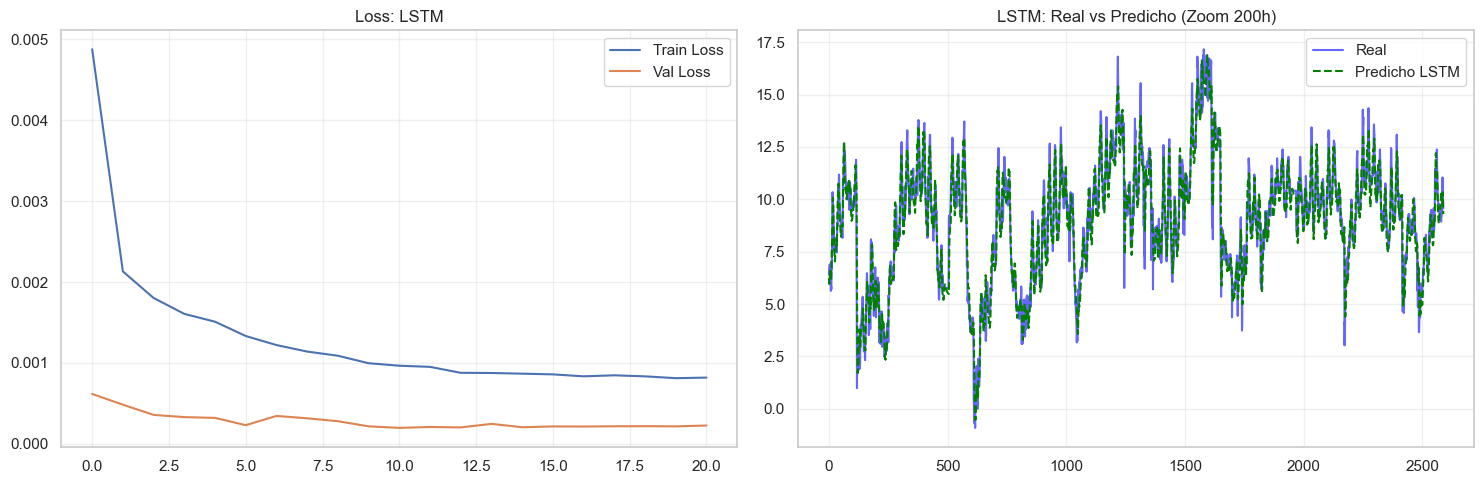

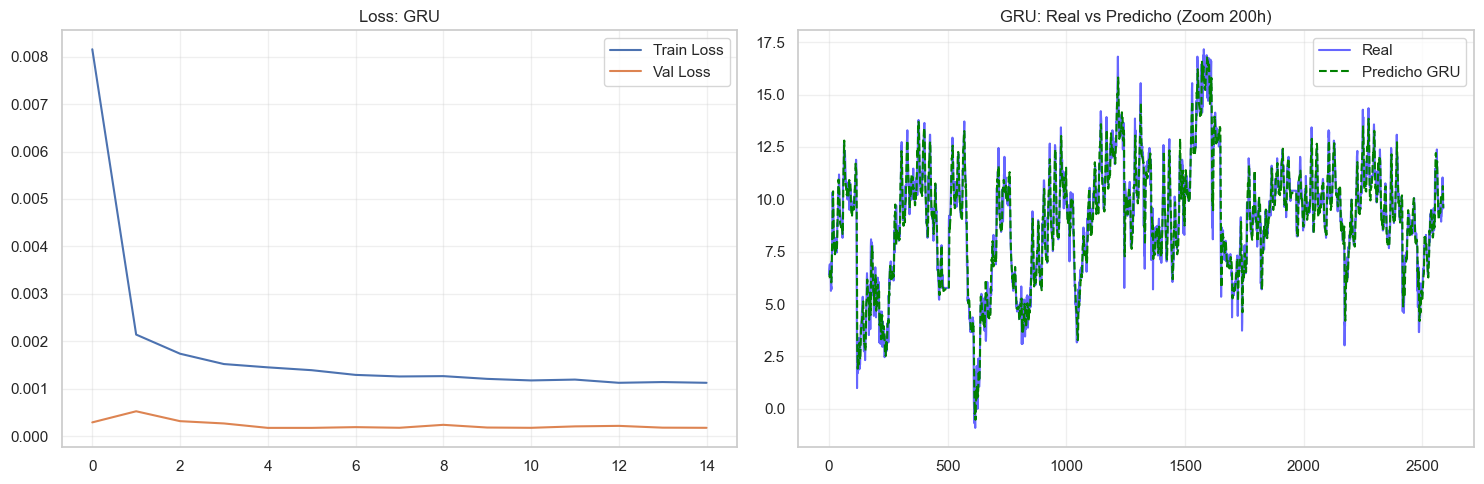

In [ ]:
for m_type in model_types:
    history = trained_histories_adv[m_type]
    model = trained_models_adv[m_type]
    
    y_test_pred = target_scaler.inverse_transform(model.predict(X_test_2, verbose=0))
    y_test_real = target_scaler.inverse_transform(y_test_2.reshape(-1, 1))
    
    plt.figure(figsize=(15, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Loss: {m_type}')
    plt.legend(); plt.grid(alpha=0.3)
    
    # Zoom 200h
    plt.subplot(1, 2, 2)
    plt.plot(y_test_real, label='Real', color='blue', alpha=0.6)
    plt.plot(y_test_pred, label=f'Predicho {m_type}', color='green', linestyle='--')
    plt.title(f'{m_type}: Real vs Predicho (Zoom 200h)')
    plt.legend(); plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(f"../images/LSTM-GRU__{m_type}.png", dpi=300, bbox_inches="tight")
    plt.show()

Al aplicar el **zoom a las primeras 200 horas**, los matices del comportamiento predictivo a corto plazo salen a la luz. A pesar de la enorme complejidad matemática de las puertas lógicas que incorporan la LSTM y la GRU, el **retraso (*lag*)** sigue estando visible. Los modelos continúan exhibiendo cierta dependencia de la "predicción ingenua" (asumir que el valor siguiente será igual al actual), reaccionando a los cambios bruscos un paso por detrás en lugar de anticiparlos. Esto se hace especialmente evidente en la profunda y repentina caída de temperatura que se registra en torno a la hora 115, donde la predicción persigue al desplome real con un ligero desfase.

Finalmente, en cuanto a la **precisión en los picos** y el ciclo diario, ambos modelos avanzados siguen mostrando la tendencia a suavizar los valores extremos, funcionando como un filtro de la señal original. No obstante, al comparar minuciosamente el encaje de ambas gráficas, la línea de predicción de la **GRU** parece ceñirse de forma sutilmente más estrecha a los recovecos de la curva real que la de la LSTM. Esta confirmación visual cierra el círculo del análisis, respaldando la conclusión numérica obtenida en la tabla de métricas: para esta ventana de 24 horas, la arquitectura GRU resulta más eficiente y ajustada que la LSTM.

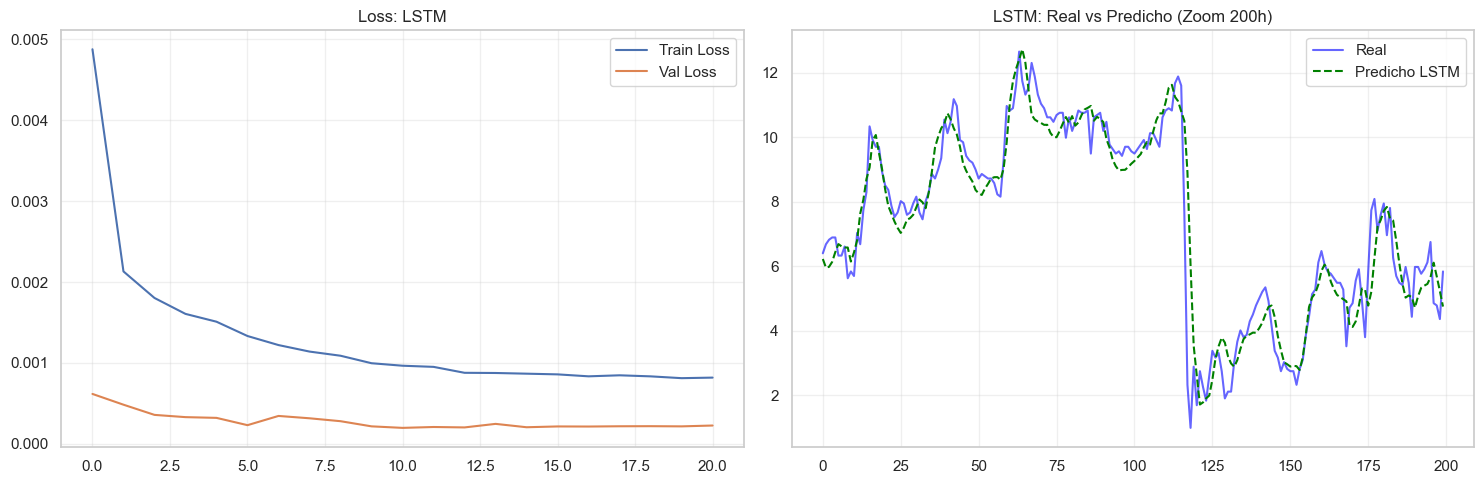

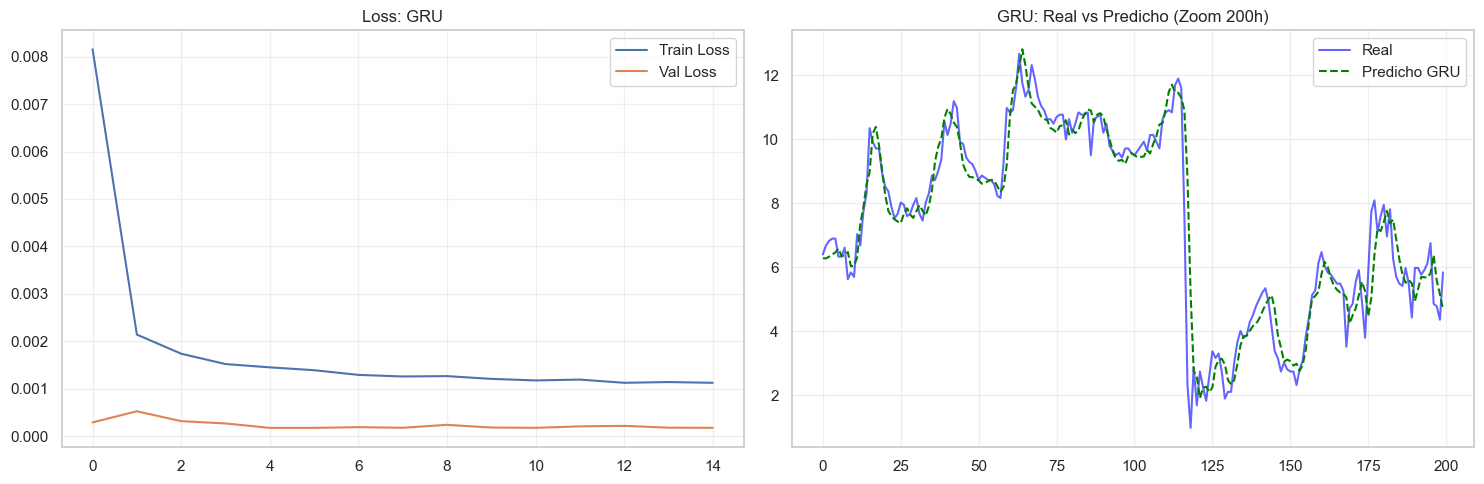

In [ ]:
for m_type in model_types:
    history = trained_histories_adv[m_type]
    model = trained_models_adv[m_type]
    
    y_test_pred = target_scaler.inverse_transform(model.predict(X_test_2, verbose=0))
    y_test_real = target_scaler.inverse_transform(y_test_2.reshape(-1, 1))
    
    plt.figure(figsize=(15, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Loss: {m_type}')
    plt.legend(); plt.grid(alpha=0.3)
    
    # Zoom 200h
    plt.subplot(1, 2, 2)
    plt.plot(y_test_real[:200], label='Real', color='blue', alpha=0.6)
    plt.plot(y_test_pred[:200], label=f'Predicho {m_type}', color='green', linestyle='--')
    plt.title(f'{m_type}: Real vs Predicho (Zoom 200h)')
    plt.legend(); plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(f"../images/LSTM-GRU__{m_type}_subsample200.png", dpi=300, bbox_inches="tight")
    plt.show()

En conclusión, la comparativa demuestra el principio de parsimonia en Deep Learning. Cuando las dependencias temporales son a corto plazo (un ciclo diario), introducir arquitecturas complejas (LSTM) junto con fuerte regularización puede degradar el rendimiento. La elección de la arquitectura debe estar guiada por la ventana de contexto necesaria, siendo la SimpleRNN o la GRU las opciones más eficientes para este pronóstico a corto plazo.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Pregunta: Realiza un breve análisis de la comparación de resultados entre SimpleRNN, LSTM y GRU. Indica si se aprecia overfitting en algún modelo.</strong> </p>

<p><strong>Solución: El analisis se ha realizado junto a los resultados obtenidos en cada apartado</strong> </p>
</div>

# 3. LSTM con PyTorch

En este ejercicio implementarás un modelo LSTM para predicción de series temporales usando **PyTorch**.

Hasta ahora los modelos recurrentes se han implementado con TensorFlow/Keras, donde el entrenamiento se realiza mediante `model.fit()`. En PyTorch, en cambio, el entrenamiento se controla de forma explícita mediante un **bucle de entrenamiento manual**, lo que ofrece mayor flexibilidad.

Dado que PyTorch no se ha trabajado todavía en profundidad en la asignatura, el ejercicio se plantea de forma guiada, proporcionando la estructura básica del código que deberás completar, ejecutar y analizar.

**IMPORTANTE: Es recomendable realizar este ejercicio para preparar las próximas PEC, que serán en PyTorch. Si decides no hacerlo, puedes continuar con el resto de ejercicios, pero tendrás que realizar el Ejecicio 6 de búsqueda de hiperparámetros con Optuna para poder conseguir un 10 en la PEC.**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF;padding: 0.5em; line-height: 1.1;">

**Ejercicio [1 pts.].** Continúa el ejercicio anterior, pero ahora implementa los modelos recurrentes usando PyTorch en lugar de TensorFlow/Keras. Para ello:

**Paso 1. Preparación de datos**

Usa el mismo dataset (ETTh1) y preprocesamiento que en los ejercicios anteriores. Reutiliza las secuencias de entrada, particiones de entrenamiento/validación/test y normalización ya definidas.

**Paso 2. Conversión de datos a tensores de PyTorch**

PyTorch trabaja con objetos llamados tensores (`torch.Tensor`).Convierte los datos de entrenamiento, validación y test a tensores usando `torch.tensor(..., dtype=torch.float32)`.

**Paso 3. Creación de TensorDataset y DataLoader**

En PyTorch los datos suelen gestionarse mediante dos estructuras:
- `TensorDataset`. Agrupa los tensores de entrada y salida. `TensorDataset(X, y)`.
- `DataLoader`. Permite: iterar por batches, barajar los datos y  alimentar el modelo durante el entrenamiento. Debes crear tres `DataLoader`:
    - entrenamiento (`shuffle=True`)
    - validación (`shuffle=False`)
    - test (`shuffle=False`)

Usa el mismo **tamaño de batch** que en los ejercicios anteriores.

**Paso 4. Implementación del modelo LSTM**

En PyTorch los modelos se implementan creando una clase que hereda de `torch.nn.Module`. Debes definir un modelo con la siguiente arquitectura:
    - Una capa `LSTM`.
    - Una capa `Dropout`.
    - Una capa de salida `Linear` para predicción de la serie temporal.

**Constructor `__init__`**

En el constructor debes definir las capas del modelo:
- `nn.LSTM`
- `nn.Dropout`
- `nn.Linear`

El número de neuronas ocultas debe ser el mismo usado en los ejercicios anteriores

**Método `forward`**

El método `forward()` define cómo fluye la información a través del modelo.

Pasos que debes implementar:
1. Pasar la secuencia de entrada `x` por la capa LSTM
2. Seleccionar la salida correspondiente al último instante temporal
3. Aplicar dropout
4. Pasar el resultado por la capa lineal para obtener la predicción final

**Paso 5. Configuración del entrenamiento**

Define los elementos necesarios para entrenar el modelo:
- **Función de pérdida**. Usa el MSE: `criterion = nn.MSELoss()`
- **Optimizador**. Usa el optimizador **Adam**: `optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)`

**Paso 6. Implementación del bucle de entrenamiento manual**

A diferencia de Keras, en PyTorch el entrenamiento debe implementarse manualmente.

Para cada epoch:

**Paso 6.1. Fase de entrenamiento**

Primero pon el modelo en modo entrenamiento: `model.train()`. Después itera sobre los batches del `DataLoader` de entrenamiento (creado en el paso 3).

Para cada batch:
1. Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`).
2. Reinicia los gradientes `optimizer.zero_grad()`.
3. Realiza la propagación hacia adelante `pred = model(xb)`.
4. Calcula la pérdida `loss = criterion(pred, yb)`.
5. Realiza la backpropagation `loss.backward()`.
6. Actualiza los pesos `optimizer.step()`.

Acumula la pérdida media de entrenamiento de cada epoch.

**Paso 6.2. Fase de validación**

Después de cada epoch evalúa el modelo en el conjunto de validación.

1. Cambia el modelo a modo evaluación `model.eval()`.
2. Desactiva el cálculo de gradientes `with torch.no_grad():`.
3. Itera sobre el `DataLoader` de validación y calcula la pérdida.

En esta fase **NO** se debe:
- hacer `backward()`
- actualizar los pesos

**Paso 7. Evaluación del modelo**

Una vez entrenado el modelo, evalúalo en entrenamiento, validación y test

**Paso 8. Comparación de resultados**

Calcula RMSE y MAE en entrenamiento, validación y test. Incluye los nuevos resultados en la tabla comparativa y analiza los resultados obtenidos.




<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>

Al evaluar el conjunto de **Test**, las arquitecturas menos parametrizadas (la **SimpleRNN** y la **GRU** implementadas en Keras) mantienen su liderazgo indiscutible, compartiendo un MAE de $0.48^\circ C$ y demostrando ser las estructuras más eficientes para capturar el ciclo térmico diario.

Por otro lado, mientras que la LSTM de Keras obtuvo los peores resultados globales (MAE de 0.58 en Test), su homóloga matemática programada en PyTorch ha logrado reducir ese error a **0.50**, empatando en el RMSE (0.70) con la GRU. Aún más destacable es su desempeño en el conjunto de **Entrenamiento**, donde la LSTM de PyTorch alcanza un RMSE de **0.98**, el valor más bajo de toda la tabla, superando con creces el pobre ajuste de la LSTM de Keras (1.14).

La diferencia entre los modelos LSTM de Keras y el modelo LSTM de pytorch no residen en las ecuaciones de la red, si no en la **dinamica del bucle de entrenamiento:**

1. **La ausencia de EarlyStopping:** En Keras, el modelo estaba condicionado por un *callback* de parada temprana que cortaba el entrenamiento al detectar un estancamiento en la validación. En PyTorch, al implementar el bucle manualmente y prescindir de este freno, el modelo fue forzado a iterar durante las **200 épocas completas**. 
2. **Superación del Underfitting:** Como se analizó en el ejercicio 2, la LSTM de Keras sufrió *underfitting* (subajuste) porque la agresiva regularización de la capa `Dropout(0.2)` dificultaba el aprendizaje en las primeras épocas. El bucle manual de PyTorch demuestra que, si se le otorga al optimizador Adam el tiempo suficiente (200 épocas), la red es perfectamente capaz de superar la penalización del *Dropout* y encontrar un mínimo global mucho más preciso.

En conclusión, la implementación en PyTorch reivindica la capacidad predictiva de la LSTM, demostrando que puede casi igualar a los modelos más sencillos si el régimen de entrenamiento es lo suficientemente exhaustivo. No obstante, el principio de parsimonia (*Navaja de Ockham*) dicta la conclusión definitiva de esta práctica: si una **SimpleRNN** o una **GRU** pueden alcanzar una precisión ligeramente superior ($MAE = 0.48$) en muchas menos épocas, con menos parámetros y sin necesidad de forzar el entrenamiento, se confirman unánimemente como las arquitecturas idóneas para modelar este transformador eléctrico a corto plazo.

</div>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# Variables heredadas
BATCH =    BATCH
N_UNITS =  UNITS
EPOCHS =   EPOCHS
DROPOUT = 0.2

In [ ]:
# Conversión de datos a tensores
# Uso .reshape(-1, 1) en las 'y' para que tengan forma [batch, 1] y no [batch]
X_train_t = torch.tensor(X_train_2, dtype=torch.float32)
y_train_t = torch.tensor(y_train_2, dtype=torch.float32).reshape(-1, 1)

X_val_t = torch.tensor(X_val_2, dtype=torch.float32)
y_val_t = torch.tensor(y_val_2, dtype=torch.float32).reshape(-1, 1)

X_test_t = torch.tensor(X_test_2, dtype=torch.float32)
y_test_t = torch.tensor(y_test_2, dtype=torch.float32).reshape(-1, 1)

# Creación del TensorDataset
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=False)

In [ ]:
# Implementación del Modelo LSTM en PyTorch
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=N_UNITS, dropout=DROPOUT):
        super().__init__()
        # batch_first=True es crucial porque los tensores son [batch, seq, features]
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)    # Capa LSTM
        self.dropout = nn.Dropout(dropout)                                                       # Capa Dropout
        self.fc = nn.Linear(hidden_size, 1)                                                      # Capa Linear

    def forward(self, x):
        out, _ = self.lstm(x)     # Pasar la secuencia de entrada `x` por la capa LSTM
        out = out[:, -1, :]       # Seleccionar la salida correspondiente al último instante temporal
        out = self.dropout(out)   # Aplicar dropout
        out = self.fc(out)        # Pasar el resultado por la capa lineal para obtener la predicción final
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Entrenamiento
def train_model(model):
    model.to(device)                                          # Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`).
    criterion = nn.MSELoss()                                  #  Función de pérdida
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #  Optimizador

    for epoch in range(EPOCHS):
        # ENTRENAMIENTO
        model.train()                               # Pon el modelo en modo entrenamiento
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb =  xb.to(device), yb.to(device)  # Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`)

            optimizer.zero_grad()                   # Reinicia los gradientes
            pred = model(xb)                        # Realiza la propagación hacia adelante
            loss = criterion(pred, yb)              # Calcula la pérdida
            loss.backward()                         # Realiza la backpropagation
            optimizer.step()                        # Actualiza los pesos

            train_loss += loss.item()               # Acumula la pérdida del batch actual (loss.item() convierte el tensor de PyTorch a un valor numérico de Python)
        train_loss /= len(train_loader)             # Calcula la pérdida media de entrenamiento dividiendo entre el número total de batches

        # VALIDACIÓN
        model.eval()                                   # Cambia el modelo a modo evaluación
        val_loss = 0
        with torch.no_grad():                          # Desactiva el cálculo de gradientes
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)  # Mueve los datos al dispositivo correspondiente (`cpu` o `gpu`)
                pred = model(xb)                       # Realiza la propagación hacia adelante
                loss = criterion(pred, yb)             # Calcula la pérdida

                val_loss += loss.item()                # Acumula la pérdida del batch actual durante la fase de validación
        val_loss /= len(val_loader)                    # Calcula la pérdida media de validación dividiendo entre el número total de batches

        print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {train_loss:.5f} - val_loss: {val_loss:.5f}")

# Evaluación del modelo
def evaluate_model(model, loader):
    model.eval()                                # Pon el modelo en modo evaluación
    preds = []
    trues = []

    with torch.no_grad():                       # Desactiva el cálculo de gradientes para ahorrar memoria y acelerar la evaluación
        for xb, yb in loader:                   # Itera sobre los batches del DataLoader
            xb = xb.to(device)                  # Mueve los datos al dispositivo correspondiente
            pred = model(xb).cpu().numpy()      # Realiza la predicción del modelo y la convierte de tensor de PyTorch a array de NumPy
            preds.append(pred)                  # Guarda las predicciones del batch en la lista
            trues.append(yb.numpy())            # Guarda los valores reales del batch en la lista

    preds = np.vstack(preds)                    # Une verticalmente todas las predicciones de los batches en un único array
    trues = np.vstack(trues)                    # Une verticalmente todos los valores reales en un único array

    # Desescalamos antes de medir el error para poder comparar con Keras
    preds_real = target_scaler.inverse_transform(preds)
    trues_real = target_scaler.inverse_transform(trues)

    # Cálculo de errores (incluido el MSE para tener las 3 métricas)
    mse = mean_squared_error(trues_real, preds_real)
    rmse = root_mean_squared_error(trues_real, preds_real)
    mae = mean_absolute_error(trues_real, preds_real)

    return mse, rmse, mae

In [ ]:
# Definición de la LSTM
lstm_model = LSTMModel(input_size=N_FEATURES)

# Entrenamiento del modelo
train_model(lstm_model)

# Evaluación del modelo
lstm_train_mse, lstm_train_rmse, lstm_train_mae = evaluate_model(lstm_model, train_loader)
lstm_val_mse, lstm_val_rmse, lstm_val_mae = evaluate_model(lstm_model, val_loader)
lstm_test_mse, lstm_test_rmse, lstm_test_mae = evaluate_model(lstm_model, test_loader)

# Creamos una lista con los resultados específicos del modelo de PyTorch
resultados_pytorch = [
    {"Window Size": 24, "Conjunto": "Entrenamiento", "MSE": round(lstm_train_mse, 4), "RMSE": round(lstm_train_rmse, 4), "MAE": round(lstm_train_mae, 4), "Modelo": "LSTM (PyTorch)"},
    {"Window Size": 24, "Conjunto": "Validación", "MSE": round(lstm_val_mse, 4), "RMSE": round(lstm_val_rmse, 4), "MAE": round(lstm_val_mae, 4), "Modelo": "LSTM (PyTorch)"},
    {"Window Size": 24, "Conjunto": "Test", "MSE": round(lstm_test_mse, 4), "RMSE": round(lstm_test_rmse, 4), "MAE": round(lstm_test_mae, 4), "Modelo": "LSTM (PyTorch)"}
]

# Lo convertimos a DataFrame temporal
df_pytorch = pd.DataFrame(resultados_pytorch)

# Concatenamos tu df_final (Keras) con el nuevo df_pytorch para crear el dataframe final
df_final_pytorch = pd.concat([df_final, df_pytorch], ignore_index=True)

# Mostramos la tabla ordenada por Conjunto y luego por RMSE para ver el ranking
print("\nCOMPARATIVA FINAL DE ARQUITECTURAS (WS=24) - KERAS VS PYTORCH:")
print(df_final_pytorch.sort_values(by=['Conjunto', 'RMSE']).to_string(index=False))

Epoch 1/200 - train_loss: 0.01422 - val_loss: 0.00350
Epoch 2/200 - train_loss: 0.00236 - val_loss: 0.00090
Epoch 3/200 - train_loss: 0.00196 - val_loss: 0.00040
Epoch 4/200 - train_loss: 0.00167 - val_loss: 0.00054
Epoch 5/200 - train_loss: 0.00156 - val_loss: 0.00086
Epoch 6/200 - train_loss: 0.00145 - val_loss: 0.00048
Epoch 7/200 - train_loss: 0.00135 - val_loss: 0.00029
Epoch 8/200 - train_loss: 0.00134 - val_loss: 0.00037
Epoch 9/200 - train_loss: 0.00119 - val_loss: 0.00029
Epoch 10/200 - train_loss: 0.00114 - val_loss: 0.00049
Epoch 11/200 - train_loss: 0.00110 - val_loss: 0.00044
Epoch 12/200 - train_loss: 0.00101 - val_loss: 0.00027
Epoch 13/200 - train_loss: 0.00095 - val_loss: 0.00023
Epoch 14/200 - train_loss: 0.00093 - val_loss: 0.00026
Epoch 15/200 - train_loss: 0.00091 - val_loss: 0.00026
Epoch 16/200 - train_loss: 0.00086 - val_loss: 0.00041
Epoch 17/200 - train_loss: 0.00081 - val_loss: 0.00024
Epoch 18/200 - train_loss: 0.00077 - val_loss: 0.00020
Epoch 19/200 - trai

In [ ]:
# Definir la ruta en tu Drive (creamos una carpeta específica para PyTorch)
save_dir_pt = "../PyTorch_Models"
if not os.path.exists(save_dir_pt):
    os.makedirs(save_dir_pt)

# Definir el nombre del archivo
modelo_pt_filename = f"{save_dir_pt}/lstm_pytorch_ws_{WS_BEST}.pth"

# Guardar el diccionario de estados (pesos) del modelo
torch.save(lstm_model.state_dict(), modelo_pt_filename)

# 4. Predicción multistep con atención

En este ejercicio se abordará un problema de **predicción multistep** en series temporales. A diferencia de los ejercicios anteriores, donde el modelo predecía solo el siguiente instante, ahora el modelo deberá predecir **varios pasos consecutivos en el futuro** a partir de una ventana de observaciones pasadas.

Supongamos que tenemos una serie temporal y que la última observación disponible ocurre en el instante `t`. El objetivo del modelo es predecir una secuencia completa de valores futuros consecutivos:

`t+1, t+2, t+3, ..., t+n`

Es decir, el modelo produce `n` predicciones seguidas en el tiempo. Es importante notar que todas estas predicciones se generan **simultáneamente en una única inferencia** del modelo. Esto es diferente de otro tipo de problema en series temporales donde se predicen **instantes específicos separados**, por ejemplo: `t+1, t+12, t+24`. Este segundo caso es común en predicción meteorológica o energética, donde interesa estimar valores a ciertas horas concretas del futuro.

En este ejercicio trabajaremos con predicción multistep directa, donde el modelo aprende a generar todo el horizonte futuro a la vez.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2.5 pts.].** En este ejercicio vas a construir un modelo LSTM con mecanismo de atención para predecir múltiples pasos futuros de la serie temporal ETTh1. Además, explorarás qué partes de la secuencia de entrada influyen más en las predicciones mediante visualización de los pesos de atención.
- Usa el dataset ETTh1.
- Modifica la función para crear secuencias para poder realizar predicciones a múltipes pasos adelante (multistep prediction).
- Divide los datos en un 70% para entrenamiento, 15% validación y 15% test. Escala los valores entre 0 y 1.
- Implementa un modelo secuencial en Tensorflow con:
    - Una capa `LSTM`.
    - Una capa de atención (`Attention`) sobre los timesteps de la LSTM.
    - Una capa `Dropout`.
    - Una capa `Dense` para predecir X pasos futuros.
- Usa un tamaño de ventana de 48 y un horizonte de 10. Este horizonte de 10 implica que el modelo produce 10 predicciones simultáneamente.
- Entrena el modelo usando `EarlyStopping` y `ReduceLROnPlateau`. Usa el mismo número de neuronas, tamaño de batch y epochs que en los ejercicios anteriores.
- Calcula RMSE y MAE en entrenamiento, validación y test y añádelos a la tabla comparativa. Las métricas RMSE y MAE se calcularán **promediando el error por muestra** dentro de la ventana de predicción.
- Visualiza el error por horizonte cada horizonte de manera gráfica para el RMSE.
- Extrae los pesos de atención para algunos ejemplos de conjunto de test. Visualiza los pesos de atención sobre la secuencia de entrada para identificar qué timesteps influyen más en la predicción. ¿Que conclusiones puedes extraer en base a la gráfica?

## 4.1. Preparación de Datos

- Usa el dataset ETTh1.
- Modifica la función para crear secuencias para poder realizar predicciones a múltipes pasos adelante (multistep prediction).
- Divide los datos en un 70% para entrenamiento, 15% validación y 15% test. Escala los valores entre 0 y 1.

In [ ]:
# --- Parámetros del Ejercicio 4 ---
WS_48 = 48
HORIZON = 10
EPOCHS_ATTN = EPOCHS
BATCH_ATTN = BATCH
UNITS_ATTN = UNITS

# Generación de secuencias
print("Generando secuencias multistep...")
X_train_multi, y_train_multi = create_sequences_multistep(train_scaled, WS_48, HORIZON)
X_val_multi, y_val_multi = create_sequences_multistep(val_scaled, WS_48, HORIZON)
X_test_multi, y_test_multi = create_sequences_multistep(test_scaled, WS_48, HORIZON)

print(f"X_train shape: {X_train_multi.shape} | y_train shape: {y_train_multi.shape}")

Generando secuencias multistep...


NameError: name 'create_sequences_multistep' is not defined

## 4.2. Definición y Entrenamiento del Modelo LSTM + Attention

- Implementa un modelo secuencial en Tensorflow con:
    - Una capa `LSTM`.
    - Una capa de atención (`Attention`) sobre los timesteps de la LSTM.
    - Una capa `Dropout`.
    - Una capa `Dense` para predecir X pasos futuros.
- Usa un tamaño de ventana de 48 y un horizonte de 10. Este horizonte de 10 implica que el modelo produce 10 predicciones simultáneamente.
- Entrena el modelo usando `EarlyStopping` y `ReduceLROnPlateau`. Usa el mismo número de neuronas, tamaño de batch y epochs que en los ejercicios anteriores.

In [ ]:
# Semillas
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# Capa de Entrada
inputs = Input(shape=(WS_48, N_FEATURES))

# Capa LSTM 
lstm_out = LSTM(UNITS_ATTN, return_sequences=True, activation="tanh")(inputs)

# Capa de Atención (Self-Attention)
# Le pasamos [query, value]. Retornamos los scores para graficarlos luego.
attn_out, attn_weights = Attention()([lstm_out, lstm_out], return_attention_scores=True)

# Agrupación y regularización
# Comprimimos la salida temporal a un vector plano usando la media global
pooled = GlobalAveragePooling1D()(attn_out)
drop = Dropout(0.2)(pooled)

# Capa de Salida (Predice 10 pasos a la vez)
outputs = Dense(HORIZON)(drop)

# Compilamos el modelo principal
model_attn = Model(inputs=inputs, outputs=outputs, name="LSTM_Attention")
model_attn.compile(optimizer="adam", loss="mean_squared_error")

# --- Modelo secundario para extraer los pesos ---
# Este modelo recibe la misma entrada pero devuelve la matriz de atención
attention_extractor = Model(inputs=inputs, outputs=attn_weights)

model_attn.summary()

# --- Callbacks y Entrenamiento ---
early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

print("\nEntrenando LSTM + Attention...")
history_attn = model_attn.fit(
    X_train_multi, y_train_multi,
    validation_data=(X_val_multi, y_val_multi),
    epochs=EPOCHS_ATTN,
    batch_size=BATCH_ATTN,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

In [ ]:
# 1. Definir la ruta en tu Drive para este ejercicio
save_dir_ex4 = "/content/drive/MyDrive/Deep-learning/Módulo 3 - Redes neuronales recurrentes (RNN)/LSTM_Attention"
if not os.path.exists(save_dir_ex4):
    os.makedirs(save_dir_ex4)

# Guardar el modelo principal (el que hace las predicciones)
model_attn.save(f"{save_dir_ex4}/modelo_lstm_attention.keras")

# Guardar el modelo extractor (el que saca los pesos para graficar)
attention_extractor.save(f"{save_dir_ex4}/modelo_extractor_attention.keras")

# Guardar el historial de entrenamiento
with open(f"{save_dir_ex4}/historia_lstm_attention.pkl", 'wb') as f:
    pickle.dump(history_attn.history, f)

In [ ]:
save_dir_ex4 = "../LSTM_Attention"

# Cargar los modelos
model_attn = load_model(f"{save_dir_ex4}/modelo_lstm_attention.keras")
attention_extractor = load_model(f"{save_dir_ex4}/modelo_extractor_attention.keras")

# Cargar el historial (por si quieres volver a graficar las curvas de loss)
with open(f"{save_dir_ex4}/historia_lstm_attention.pkl", 'rb') as f:
    history_attn_recuperado = pickle.load(f)

## 4.3. Evaluación, Métricas y Actualización de Tabla

- Calcula RMSE y MAE en entrenamiento, validación y test y añádelos a la tabla comparativa. Las métricas RMSE y MAE se calcularán **promediando el error por muestra** dentro de la ventana de predicción.


In [ ]:
# Cálculos
mse_tr, rmse_tr, mae_tr, _, _ = evaluate_multistep(model_attn, X_train_multi, y_train_multi)
mse_v, rmse_v, mae_v, _, _ = evaluate_multistep(model_attn, X_val_multi, y_val_multi)
mse_te, rmse_te, mae_te, y_real_test, y_pred_test = evaluate_multistep(model_attn, X_test_multi, y_test_multi)

# Añadimos a la tabla (Asumiendo que tu df_final_pytorch está en memoria)
resultados_attn = [
    {"Window Size": WS_48, "Conjunto": "Entrenamiento", "MSE": round(mse_tr, 4), "RMSE": round(rmse_tr, 4), "MAE": round(mae_tr, 4), "Modelo": "LSTM + Attention"},
    {"Window Size": WS_48, "Conjunto": "Validación", "MSE": round(mse_v, 4), "RMSE": round(rmse_v, 4), "MAE": round(mae_v, 4), "Modelo": "LSTM + Attention"},
    {"Window Size": WS_48, "Conjunto": "Test", "MSE": round(mse_te, 4), "RMSE": round(rmse_te, 4), "MAE": round(mae_te, 4), "Modelo": "LSTM + Attention"}
]

df_con_attn = pd.concat([df_final_pytorch, pd.DataFrame(resultados_attn)], ignore_index=True)
print("\nTABLA FINAL ACTUALIZADA:")
print(df_con_attn[df_con_attn['Conjunto'] == 'Test'].sort_values(by='RMSE').to_string(index=False))

## 4.4. Visualizaciones

- Visualiza el error por horizonte cada horizonte de manera gráfica para el RMSE.
- Extrae los pesos de atención para algunos ejemplos de conjunto de test. Visualiza los pesos de atención sobre la secuencia de entrada para identificar qué timesteps influyen más en la predicción. 

In [ ]:
# 1. Gráfica de RMSE por cada horizonte de predicción (1 al 10)
rmse_por_horizonte = []
for h in range(HORIZON):
    # Calculamos el RMSE solo para la columna 'h'
    err = root_mean_squared_error(y_real_test[:, h], y_pred_test[:, h])
    rmse_por_horizonte.append(err)

plt.figure(figsize=(10, 4))
plt.plot(range(1, HORIZON + 1), rmse_por_horizonte, marker='o', linestyle='-', color='purple')
plt.title("Degradación del RMSE según el horizonte de predicción")
plt.xlabel("Horizonte futuro (Horas)")
plt.ylabel("RMSE (°C)")
# ... (código anterior de la gráfica) ...
plt.xticks(range(1, HORIZON + 1))
plt.grid(alpha=0.3)

# Añadir esta línea antes del show:
plt.savefig(f"{save_dir_ex4}/Degradacion_RMSE_Horizonte.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Extracción y visualización de Pesos de Atención
# Tomamos una muestra aleatoria del test
sample_idx = 100 
X_sample = X_test_multi[sample_idx:sample_idx+1]

# Extraemos la matriz de atención (Forma: [1, 48, 48])
pesos_attn = attention_extractor.predict(X_sample, verbose=0)
# Promediamos la atención sobre todas las "queries" para ver qué timesteps pasados importan más
pesos_promedio = np.mean(pesos_attn[0], axis=0) 

plt.figure(figsize=(12, 4))
plt.bar(range(WS_48), pesos_promedio, color='orange')
plt.title("Pesos de Atención: Importancia de cada hora pasada (Ventana 48h)")
# ... (código anterior de la gráfica) ...
plt.xlabel("Pasos hacia atrás (0 = Hace 48h, 47 = Última hora registrada)")
plt.ylabel("Peso de Atención (Importancia)")
plt.grid(axis='y', alpha=0.3)

# Añadir esta línea antes del show:
plt.savefig(f"{save_dir_ex4}/Pesos_Atencion_Muestra{sample_idx}.png", dpi=300, bbox_inches="tight")
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
<p><strong>¿Que conclusiones puedes extraer en base a la gráfica?:</strong> </p>
</div>

# 5. Problema de clasificación de texto

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio [2 pts.].** Aplica redes neuronales recurrentes al problema de clasificación de texto utilizando un modelo GRU y el dataset **AG News**. El objetivo es construir un clasificador capaz de asignar cada noticia a una de sus cuatro categorías (world, sports, business y science/technology). Para ello:
- Carga el dataset **AG News** usando `Tensorflow Datasets`. Más información sobre el dataset: https://www.tensorflow.org/datasets/catalog/ag_news_subset?hl=es-419
- Realiza el preprocesado de los textos:
    - Tokeniza los textos y limita el vocabulario a 20 000 palabras.
    - Convierte los textos en secuencias numéricas.
    - Aplica *padding* o *truncation* para que todas las secuencias tengan una longitud fija de 100.
    - Divide los datos en un 80% para entrenamiento y 20% para test.
- Construye un modelo secuencial con:
    - Una capa `Embedding` de dimensión 128.
    - Una capa `GRU`.
    - Una capa `Dropout`.
    - Una capa de salida `Dense`.

- Entrena el modelo utilizando `EarlyStopping`.
- Evalúa el rendimiento del modelo usando la métrica de `accuracy`, calcula la matriz de confusión y muestra el classification report.
- Visualiza las curvas de loss de entrenamiento y validación.

Finalmente, responde a las siguientes cuestiones:
- ¿Por qué es necesario que todas las secuencias tengan la misma longitud?
- ¿Qué efecto tendría truncar las secuencias de forma demasiado agresiva sobre el rendimiento del clasificador?

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

# 6. (Opcional) Búsqueda de hiperparámetros con Optuna

La **búsqueda de hiperparámetros** es el proceso de encontrar la mejor combinación posible de parámetros que no son aprendidos automáticamente por el modelo, como el número de unidades de una capa, la tasa de aprendizaje o el tamaño del batch. Una buena elección de estos valores puede mejorar notablemente el rendimiento del modelo.

**Optuna** (https://optuna.org/) es una librería de optimización automática que utiliza estrategias como *Tree-structured Parzen Estimator* (TPE) para explorar de manera eficiente el espacio de hiperparámetros. Permite definir un objetivo que entrena y evalúa el modelo con diferentes combinaciones, encontrando la que maximiza o minimiza una métrica determinada.

**IMPORTANTE. Este ejercicio es opcional:**

- Si **no** has realizado el Ejercicio 3 (LSTM con PyTorch), deberás realizar este ejercicio para poder alcanzar la puntuación máxima de 10 puntos en la PEC.

- Si **sí** has realizado el Ejercicio 3, también puedes realizar este ejercicio adicionalmente. En ese caso, este ejercicio podrá sumar hasta 1 punto, pero la calificación final de la actividad no podrá superar los 10 puntos.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio Opcional [1 pts.].** En este ejercicio se pretende mejorar el rendimiento del modelo de clasificación de noticias construido en el ejercicio anterior mediante la búsqueda automática de hiperparámetros. Para ello se utilizará la librería Optuna para optimizar la arquitectura y los parámetros de entrenamiento del modelo basado en redes neuronales recurrentes.

Partiendo del dataset AG News y del preprocesado ya realizado (tokenización, secuencias numéricas, padding a longitud fija y partición train/test), se deberán llevar a cabo los siguientes pasos:

- Implementa una función objetivo (objective function) compatible con Optuna que:
    - Construye un modelo de clasificación de texto.
    - Permita ajustar al menos tres de los siguientes hiperparámetros:
        - Número de neuronas de la capa recurrente.
        - Dimensión de la capa `Embedding`.
        - Tasa de `Dropout`.
        - Learning rate del optimizador `Adam`.
        - Tamaño del batch.
    - Entrene el modelo durante pocas épocas (por ejemplo, 5) usando un subconjunto de validación.
    - Devuelva como métrica objetivo el mejor accuracy.
- Crea un estudio de optuna y ejecuta al menos 3 trials.
- Muestra los mejores hiperparámetros encontrados y el mejor accuracy.
- Utiliza los mejores hiperparámetros obtenidos para construir un modelo final, entrenarlo y evaluarlo.
- Analiza los resultados del modelo final. Para ello calcula la matriz de confusión y muestra el classification report.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [ ]:
def objective(trial):
    # Hiperparámetros a optimizar


    # Callbacks


    # Modelo GRU


    # Entrenamiento


    return # accuracy

<div style="background-color: #c3fac4; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Fuentes:</strong>
<br><br>
Pon aquí las fuentes utilizadas en la elaboración de la PEC (incluyendo herramientas de IA generativa).
<br><br>
    <ul>
        <li>Origen de los datos: [ETDataset](https://arxiv.org/abs/2012.07436)</li>
    </ul>
    <ul>
        <li><strong>Fuentes utilizadas en el ejercicio 1:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 2:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 3:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 4:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 5:</strong> (escribe aquí tu respuesta)</li>
        <li><strong>Fuentes utilizadas en el ejercicio 6:</strong> (escribe aquí tu respuesta)</li>        
    </ul>
</div>